# Lab Day 1 — Xây dựng mạng nơ-ron và thí nghiệm huấn luyện

**MSSV:** 2A202602803 · Forest CoverType · `M-base` 54 → 256 → 128 → 7

Notebook này chạy từ đầu đến cuối bằng *Restart & Run All*: trên máy cá nhân (từ `submission_2A202602803/code/`) hoặc trên Kaggle/Colab (ô đầu tự clone repo, cần bật Internet). Thiết bị được chọn tự động: CUDA, Apple MPS, rồi CPU.
Code nằm trong các module cùng thư mục (`data.py`, `model.py`, `optimizer.py`, `train.py`, `plots.py`, `results_table.py`);
notebook chỉ đổi dict cấu hình rồi gọi `run_experiment`.

Quy ước: mọi lựa chọn cấu hình dùng **val**; tập **eval** chỉ xuất hiện ở Part 4, cho baseline và cấu hình cuối cùng.

In [1]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, math, time, subprocess, tempfile, zipfile

REPO_URL   = "https://github.com/DAQuan-VinAI/K4-Track4-Day1-Neuralnetwork.git"
SUBMISSION = "submission_2A202602803"

# Kaggle/Colab: notebook được mở rời nên chưa có repo -> clone rồi chuyển vào submission_<MSSV>/code/
if not os.path.exists("data.py"):
    base = next((d for d in ("/kaggle/working", "/content") if os.path.isdir(d)), os.getcwd())
    repo = f"{base}/K4-Track4-Day1-Neuralnetwork"
    if not os.path.isdir(repo):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, repo], check=True)
    os.chdir(f"{repo}/{SUBMISSION}/code")
sys.path.insert(0, os.getcwd())

REPO_ROOT = "../.."     # thư mục gốc repo (chứa data/ và scripts/), tính từ submission_<MSSV>/code/
OUT_DIR   = ".."        # nơi ghi figures/, results/, experiments.xlsx, predictions_eval.csv (= submission_<MSSV>/)

import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from IPython.display import Image, display

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("thư mục làm việc:", os.getcwd())
print("torch", torch.__version__, "| device:", device,
      "|", torch.cuda.get_device_name(0) if device == "cuda" else ("GPU Apple (MPS)" if device == "mps" else "CPU"))
os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
os.makedirs(f"{OUT_DIR}/results", exist_ok=True)

from data import prepare_data, iterate_batches
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, compute_loss, run_experiment, final_eval
from plots import plot_run, plot_compare, plot_lr_sweep
from results_table import save_result, load_results, to_row, write_xlsx

EPOCHS = 20   # cùng số epoch cho mọi thí nghiệm (trừ thí nghiệm về số epoch)

thư mục làm việc: /Users/doananhquan/Documents/AI thực chiến/Day 16/K4-Track4-Day1-Neuralnetwork/submission_2A202602803/code
torch 2.14.1 | device: mps | GPU Apple (MPS)


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: `scripts/split_data.py` tạo `data/processed/train.npz`, `eval.npz`.
Sau đó tách 20% validation từ train (phân tầng, seed 42), chuẩn hoá 10 cột số bằng thống kê của **phần train còn lại**, đưa mọi tensor lên device một lần.

In [2]:
proc = subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True, capture_output=True, text=True)
print(proc.stdout)

data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")

assert data["X_tr"].shape == (371_847, 54) and data["X_val"].shape == (92_962, 54) and data["X_eval"].shape == (116_203, 54)

# Tỉ lệ lớp ở ba tập (chỉ nhìn phân bố nhãn, không dùng để chọn cấu hình)
ratios = pd.DataFrame({name: torch.bincount(data[k], minlength=7).cpu().numpy() / len(data[k])
                       for name, k in [("train", "y_tr"), ("val", "y_val"), ("eval", "y_eval")]})
ratios.index.name = "lớp"
display((100 * ratios).round(3))

# Chuẩn hoá: 10 cột số trên train phải có trung bình ≈ 0, độ lệch chuẩn ≈ 1; val lệch nhẹ là bình thường
num_tr, num_val = data["X_tr"][:, :10], data["X_val"][:, :10]
print("train  | |mean| lớn nhất = %.2e, std trong [%.4f, %.4f]" % (num_tr.mean(0).abs().max(), num_tr.std(0).min(), num_tr.std(0).max()))
print("val    | |mean| lớn nhất = %.2e, std trong [%.4f, %.4f]" % (num_val.mean(0).abs().max(), num_val.std(0).min(), num_val.std(0).max()))
print("44 cột nhị phân giữ nguyên:", sorted(data["X_tr"][:, 10:].unique().tolist()))

MAJORITY_ACC = (data["y_val"] == data["y_tr"].bincount().argmax()).float().mean().item()
print(f"mốc thấp nhất (luôn đoán lớp đa số) trên val: accuracy = {MAJORITY_ACC:.4f}")

train: X (464809, 54) float32, y (464809,) int64, nhãn 0..6 -> data/processed/train.npz
eval : X (116203, 54) float32, y (116203,) int64, nhãn 0..6 -> data/processed/eval.npz

lớp   train(%)   eval(%)
  0    36.461    36.460
  1    48.760    48.760
  2     6.154     6.154
  3     0.473     0.472
  4     1.634     1.634
  5     2.989     2.989
  6     3.530     3.530

đoán luôn lớp đa số (lớp 1) cho accuracy trên eval = 0.4876



train (371847, 54) | val (92962, 54) | eval (116203, 54) | device mps
luôn đoán lớp đa số (lớp 1): val accuracy = 0.4876


,train,val,eval
lớp,,,
0,36.461,36.460,36.460
1,48.760,48.760,48.760
2,6.154,6.154,6.154
3,0.473,0.472,0.472
4,1.634,1.634,1.634
5,2.989,2.989,2.989
6,3.530,3.530,3.530


train  | |mean| lớn nhất = 3.60e-07, std trong [1.0000, 1.0000]
val    | |mean| lớn nhất = 6.26e-03, std trong [0.9981, 1.0043]
44 cột nhị phân giữ nguyên: [0.0, 1.0]


mốc thấp nhất (luôn đoán lớp đa số) trên val: accuracy = 0.4876


**Nhận xét Part 0.** Thống kê chuẩn hoá chỉ lấy từ phần train còn lại: nếu tính trên cả val/eval thì thông tin của dữ liệu "chưa thấy" lọt vào đầu vào của mô hình (rò rỉ), điểm val/eval sẽ lạc quan hơn thực tế. Ba tập có tỉ lệ lớp gần như bằng nhau vì đều chia phân tầng; lớp 3 chỉ ~0,5% nên macro-F1 (mỗi lớp trọng số như nhau) khắt khe hơn accuracy nhiều.

## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

In [3]:
# 1) Số tham số của cả ba kiến trúc, 2) shape qua từng lớp
for hidden, n_expected in EXPECTED_PARAMS.items():
    assert count_params(MLP(hidden=hidden)) == n_expected, hidden
    print(f"hidden={hidden}: {n_expected:,} tham số  ✓")

set_seed(0)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
assert count_params(model) == EXPECTED_PARAMS[(256, 128)] == 47_879
print(model)

h = torch.randn(8, 54, device=device)
print("\nđầu vào".ljust(28), tuple(h.shape))
with torch.no_grad():
    for layer in model.net:
        h = layer(h)
        print(str(layer).ljust(27), tuple(h.shape))
assert h.shape == (8, 7)

hidden=(256, 128): 47,879 tham số  ✓
hidden=(512, 256): 161,287 tham số  ✓
hidden=(256, 128, 64): 55,687 tham số  ✓
MLP(
  (net): Sequential(
    (0): Linear(in_features=54, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=128, out_features=7, bias=True)
  )
)

đầu vào                     (8, 54)
Linear(in_features=54, out_features=256, bias=True) (8, 256)
ReLU()                      (8, 256)
Dropout(p=0.0, inplace=False) (8, 256)
Linear(in_features=256, out_features=128, bias=True) (8, 128)
ReLU()                      (8, 128)
Dropout(p=0.0, inplace=False) (8, 128)
Linear(in_features=128, out_features=7, bias=True) (8, 7)


In [4]:
# 3) Loss bước 0 trên val (eval mode), kỳ vọng quanh ln 7
ln7 = math.log(7)
step0 = evaluate(model, data["X_val"], data["y_val"], "ce")
print(f"loss bước 0 (init he)      = {step0['loss']:.4f}   | ln 7 = {ln7:.4f} | chênh = {step0['loss'] - ln7:+.4f}")
print(f"độ lệch chuẩn của logit    = {model(data['X_val'][:4096]).std().item():.3f}")

# Đối chứng: cùng mô hình nhưng lớp cuối khởi tạo nhỏ (N(0, 0.01²)) -> logit ≈ 0 -> loss phải rất sát ln 7
set_seed(0)
probe = MLP(hidden=(256, 128), init="he").to(device)
torch.nn.init.normal_(probe.net[-1].weight, std=0.01)
print(f"loss bước 0 (lớp cuối nhỏ) = {evaluate(probe, data['X_val'], data['y_val'], 'ce')['loss']:.4f}")

loss bước 0 (init he)      = 2.2073   | ln 7 = 1.9459 | chênh = +0.2614
độ lệch chuẩn của logit    = 0.610
loss bước 0 (lớp cuối nhỏ) = 1.9467


loss đầu = 1.9668 -> loss cuối = 0.00022; accuracy trên 20 mẫu = 1.00


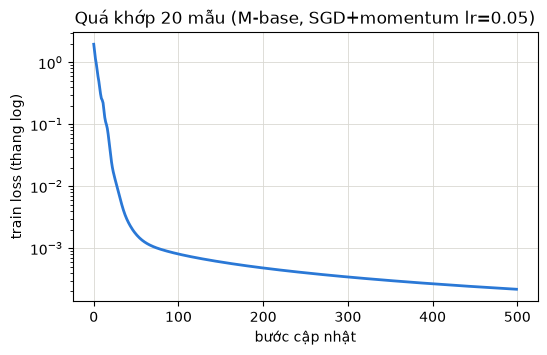

In [5]:
# 4) Quá khớp 20 mẫu: tắt dropout, vài trăm bước -> loss phải về gần 0, accuracy 100% trên 20 mẫu đó
set_seed(0)
tiny = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
xs, ys = data["X_tr"][:20], data["y_tr"][:20]
opt = build_optimizer("sgd_momentum", tiny.parameters(), lr=0.05)
overfit_losses = []
tiny.train()
for step in range(500):
    loss = compute_loss(tiny(xs), ys, "ce")
    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()
    overfit_losses.append(loss.item())
overfit_acc = (predict(tiny, xs) == ys).float().mean().item()
print(f"loss đầu = {overfit_losses[0]:.4f} -> loss cuối = {overfit_losses[-1]:.5f}; accuracy trên 20 mẫu = {overfit_acc:.2f}")
assert overfit_losses[-1] < 0.05 and overfit_acc == 1.0, "không quá khớp được 20 mẫu: gần như chắc chắn là lỗi code"

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(overfit_losses, color="#2a78d6", lw=2)
ax.set_yscale("log"); ax.set_xlabel("bước cập nhật"); ax.set_ylabel("train loss (thang log)")
ax.set_title("Quá khớp 20 mẫu (M-base, SGD+momentum lr=0.05)")
ax.grid(True, color="#d9d8d2", lw=0.6); plt.show()

In [6]:
# 5) Gradient có chảy không? Sau một lần backward, mọi tham số phải có gradient khác None và khác 0
set_seed(0)
model = MLP(hidden=(256, 128), init="he").to(device)
xb, yb = data["X_tr"][:512], data["y_tr"][:512]
compute_loss(model(xb), yb, "ce").backward()
for name, p in model.named_parameters():
    assert p.grad is not None, name
    gn = p.grad.norm().item()
    print(f"{name:14s} shape {str(tuple(p.shape)):12s} grad norm = {gn:.4e}")
    assert gn > 0, f"gradient của {name} bằng 0"
print("chuẩn L2 toàn cục:", clip_gradients(model.parameters(), None))

net.0.weight   shape (256, 54)    grad norm = 4.5429e-01
net.0.bias     shape (256,)       grad norm = 2.6839e-01
net.3.weight   shape (128, 256)   grad norm = 1.7565e+00
net.3.bias     shape (128,)       grad norm = 3.8244e-01
net.6.weight   shape (7, 128)     grad norm = 1.9387e+00
net.6.bias     shape (7,)         grad norm = 5.4980e-01
chuẩn L2 toàn cục: 2.751523733139038


**Nhận xét Part 1.**
- Số tham số khớp bảng (47 879 / 161 287 / 55 687), logits `(8, 7)`.
- Loss bước 0 với He đo được **2.2073**, cao hơn ln 7 = 1.9459 là 0.26 (logit có độ lệch chuẩn 0.61); phép đối chứng với lớp cuối khởi tạo nhỏ cho 1.9467. Lý do: He đặt `Var[W] = 2/n_vào` cho *cả lớp cuối*, nên logit ở bước 0 có độ lệch chuẩn khác 0 rõ rệt (số in ở trên) chứ không phải ≈ 0; softmax lúc đó không đều, mô hình "tự tin sai" trên một phần mẫu và CE lớn hơn ln 7. Phép đối chứng (lớp cuối khởi tạo nhỏ) cho loss sát ln 7, tức là chênh lệch đến từ thang của logit chứ không phải lỗi nhãn hay lỗi chuẩn hoá. Mức lệch này nhỏ và biến mất sau vài chục bước.
- Quá khớp 20 mẫu: loss 1.9668 → 0.00022 sau 500 bước, accuracy 100%, nên đường đi forward → loss → backward → cập nhật là đúng.
- Cả 6 tensor tham số (W1, b1, W2, b2, W3, b3) đều có gradient khác 0.

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD + momentum 0,9, CE, He, batch 512, 20 epoch, không dropout/clip, FP32.

Mỗi lần chạy được lưu thành `results/<exp_id>.json` và `figures/<exp_id>.png`.

In [7]:
RESULTS = {}   # exp_id -> result (kèm best_state trong RAM)
NOTES   = {}   # exp_id -> ghi chú cho cột notes của bảng

def register(result, note=""):
    # Lưu JSON + ảnh của một lần chạy và in một dòng tóm tắt
    exp_id = result["cfg"]["exp_id"]
    RESULTS[exp_id], NOTES[exp_id] = result, note
    save_result(result, f"{OUT_DIR}/results")
    plot_run(result, f"{OUT_DIR}/figures/{exp_id}.png")
    s = result["summary"]
    if s["best_epoch"] is None:
        print(f"{exp_id:24s} PHÂN KỲ ở epoch {s['diverged_epoch']} (loss bước 0 = {s['step0_loss']:.4f})")
    else:
        print(f"{exp_id:24s} val loss {s['best_val_loss']:.4f} @ep{s['best_epoch']:<2d} | acc {s['val_acc']:.4f} | "
              f"macro-F1 {s['val_macro_f1']:.4f} | {s['time_per_epoch_s']:.2f}s/epoch" + (" | PHÂN KỲ" if s["diverged"] else ""))
    return result

def run(note="", **overrides):
    # Chạy một thí nghiệm = baseline + các khoá bị đổi trong `overrides`
    return register(run_experiment({**BASE_CFG, **overrides}, data), note)

def f1_of(exp_id):
    v = RESULTS[exp_id]["summary"]["val_macro_f1"]
    return -1.0 if v is None else v

def show(name):
    display(Image(filename=f"{OUT_DIR}/figures/{name}.png"))

### 2a. Chọn `lr` cho baseline bằng val
Thử 4 giá trị cách nhau ~3 lần quanh vùng gợi ý (0,01 → 0,1, thêm 0,3 để thấy mép trên). Chọn giá trị có **val macro-F1** cao nhất; lần chạy được chọn trở thành `base-s1`, các lần còn lại là thí nghiệm `hp-lr…` của chủ đề hyper-parameter (chỉ khác baseline ở `lr`).

In [8]:
LR_GRID = [0.01, 0.03, 0.1, 0.3]
search = {lr: run_experiment({**DEFAULT_CFG, "lr": lr, "epochs": EPOCHS, "seed": 1, "exp_id": f"lr-search-{lr:g}"}, data)
          for lr in LR_GRID}

lr_table = pd.DataFrame([{"lr": lr, **{k: r["summary"][k] for k in
                          ("best_val_loss", "best_epoch", "val_acc", "val_macro_f1", "diverged")}} for lr, r in search.items()])
display(lr_table.round(4))

BASE_LR = max(search, key=lambda lr: -1.0 if search[lr]["summary"]["val_macro_f1"] is None else search[lr]["summary"]["val_macro_f1"])
BASE_CFG = {**DEFAULT_CFG, "lr": BASE_LR, "epochs": EPOCHS}
print(f"lr được chọn cho baseline (theo val macro-F1): {BASE_LR:g}\n")

for lr, r in search.items():
    if lr == BASE_LR:
        r["cfg"].update(exp_id="base-s1", group="baseline", description="Baseline M-base, seed 1")
        register(r, f"lr chọn bằng val trong lưới {LR_GRID}")
    else:
        r["cfg"].update(exp_id=f"hp-lr{lr:g}", group="hparam", description=f"Baseline nhưng lr={lr:g} (baseline: {BASE_LR:g})")
        register(r, "lần chạy trong lưới tìm lr của baseline")

,lr,best_val_loss,best_epoch,val_acc,val_macro_f1,diverged
0,0.01,0.3167,19,0.8714,0.7623,False
1,0.03,0.2651,20,0.8925,0.8245,False
2,0.10,0.2379,20,0.9043,0.8537,False
3,0.30,0.2276,19,0.9094,0.8539,False


lr được chọn cho baseline (theo val macro-F1): 0.3

hp-lr0.01                val loss 0.3167 @ep19 | acc 0.8714 | macro-F1 0.7623 | 0.62s/epoch


hp-lr0.03                val loss 0.2651 @ep20 | acc 0.8925 | macro-F1 0.8245 | 0.60s/epoch
hp-lr0.1                 val loss 0.2379 @ep20 | acc 0.9043 | macro-F1 0.8537 | 0.56s/epoch


base-s1                  val loss 0.2276 @ep19 | acc 0.9094 | macro-F1 0.8539 | 0.58s/epoch


### 2b. Baseline với 3 seed và độ nhiễu
Seed đổi cả khởi tạo tham số lẫn thứ tự xáo lô. Độ lệch chuẩn giữa các seed là thước đo nhiễu: chênh lệch giữa hai cấu hình nhỏ hơn **2σ** thì không coi là bằng chứng.

base-s2                  val loss 0.2133 @ep19 | acc 0.9160 | macro-F1 0.8657 | 0.58s/epoch


base-s3                  val loss 0.2199 @ep20 | acc 0.9144 | macro-F1 0.8423 | 0.57s/epoch


,val_acc,val_macro_f1,best_val_loss,best_epoch
exp_id,,,,
base-s1,0.9094,0.8539,0.2276,19
base-s2,0.9160,0.8657,0.2133,19
base-s3,0.9144,0.8423,0.2199,20


,mean,std (mẫu),2σ
val_acc,0.91329,0.00345,0.00689
val_macro_f1,0.85397,0.01168,0.02335
best_val_loss,0.22029,0.00713,0.01426


baseline: val macro-F1 = 0.8540 ± 0.0117 -> ngưỡng nhiễu 2σ = 0.0234
baseline: val acc      = 0.9133 (mốc đoán đa số 0.4876)


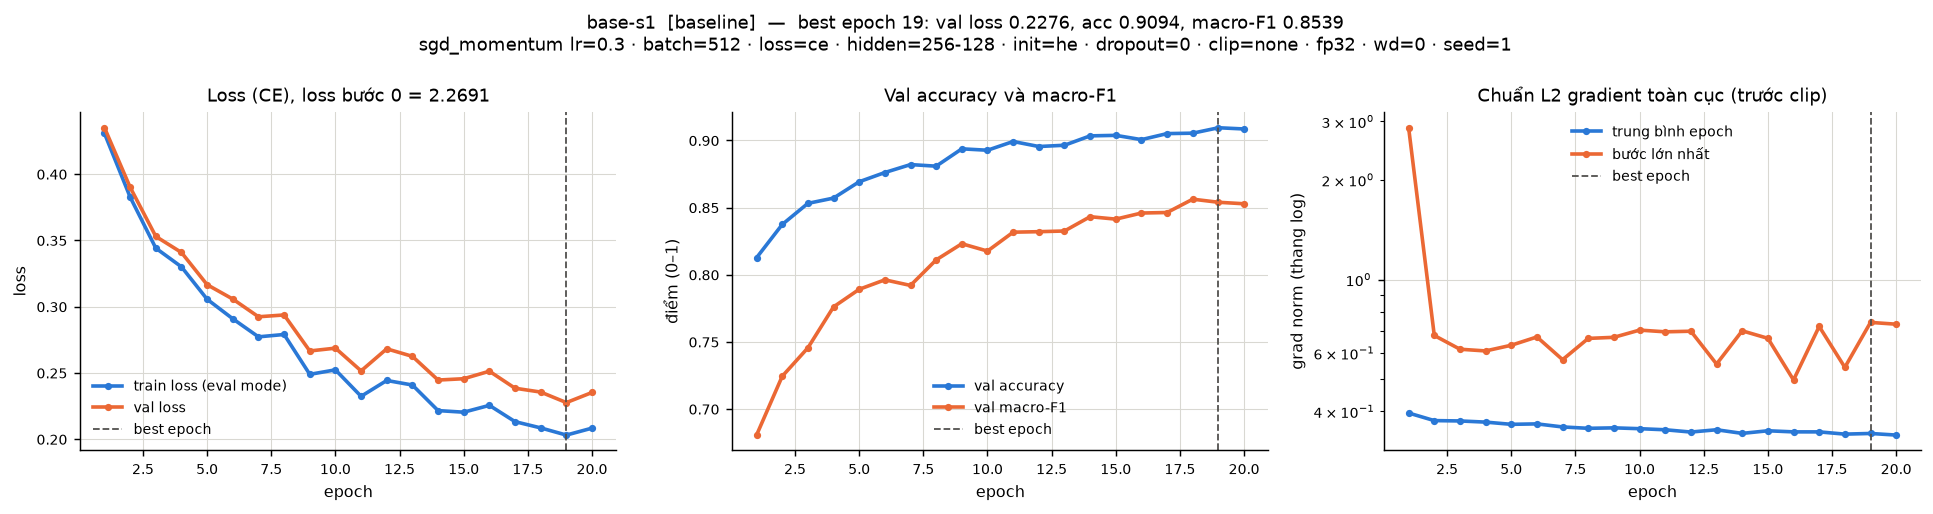

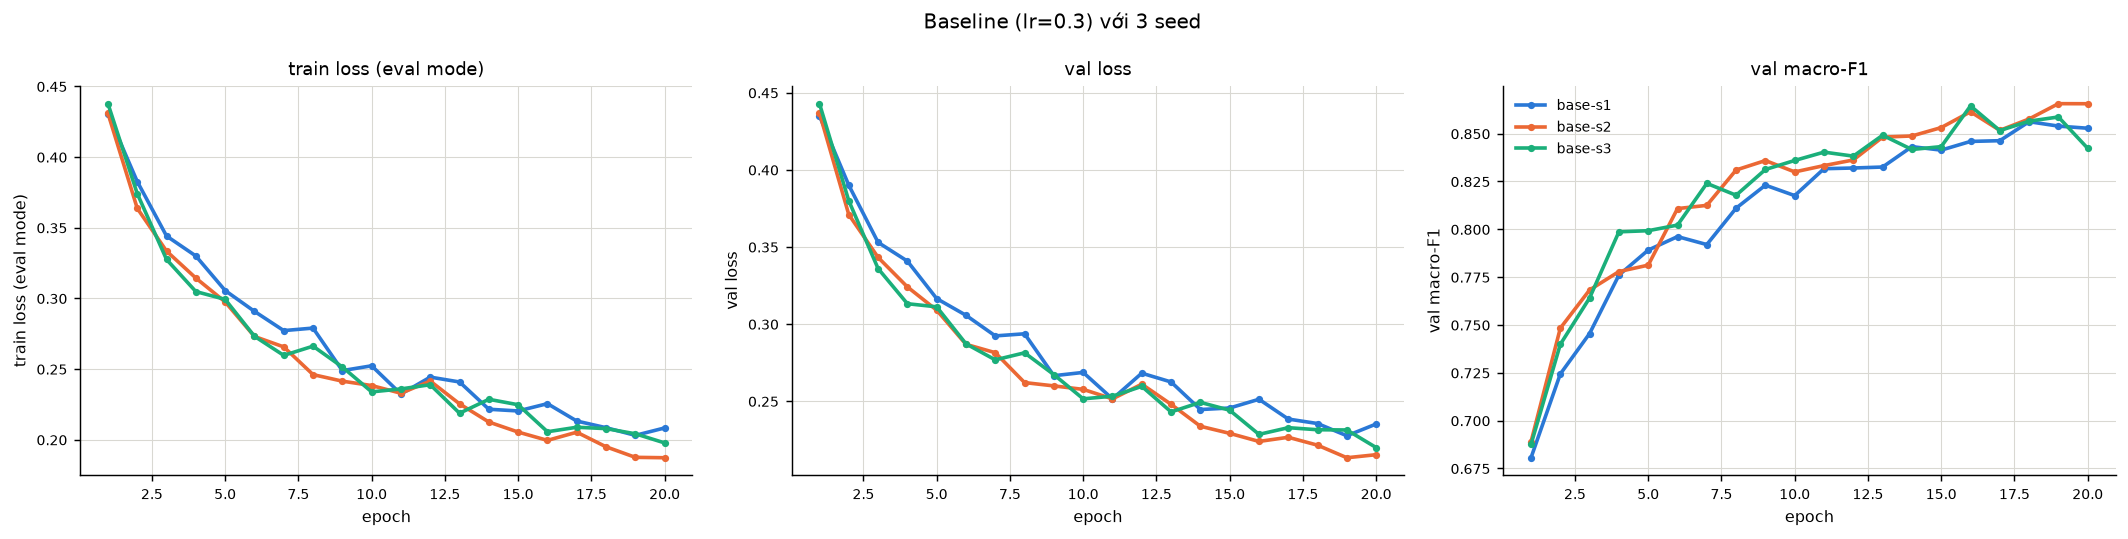

In [9]:
for seed in (2, 3):
    run(seed=seed, exp_id=f"base-s{seed}", group="baseline", description=f"Baseline M-base, seed {seed}")

BASE_IDS = ["base-s1", "base-s2", "base-s3"]
seed_table = pd.DataFrame([{"exp_id": i, **{k: RESULTS[i]["summary"][k] for k in ("val_acc", "val_macro_f1", "best_val_loss", "best_epoch")}}
                           for i in BASE_IDS]).set_index("exp_id")
stats = pd.DataFrame({"mean": seed_table.mean(), "std (mẫu)": seed_table.std(ddof=1)})
stats["2σ"] = 2 * stats["std (mẫu)"]
display(seed_table.round(4)); display(stats.drop(index="best_epoch").round(5))

BASE_F1  = stats.loc["val_macro_f1", "mean"]   # mốc so sánh = trung bình baseline (giống sheet Seeds)
NOISE_F1 = stats.loc["val_macro_f1", "2σ"]     # ngưỡng nhiễu 2σ của val macro-F1
print(f"baseline: val macro-F1 = {BASE_F1:.4f} ± {stats.loc['val_macro_f1', 'std (mẫu)']:.4f} -> ngưỡng nhiễu 2σ = {NOISE_F1:.4f}")
print(f"baseline: val acc      = {stats.loc['val_acc', 'mean']:.4f} (mốc đoán đa số {MAJORITY_ACC:.4f})")
assert seed_table["val_acc"].min() > MAJORITY_ACC

plot_compare([RESULTS[i] for i in BASE_IDS], ["train_loss", "val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_baseline.png", title=f"Baseline (lr={BASE_LR:g}) với 3 seed")
show("base-s1"); show("compare_baseline")

def compare(ids, extra=()):
    # Bảng so sánh với baseline: Δ macro-F1 so với trung bình baseline và có vượt ngưỡng nhiễu 2σ không
    rows = []
    for i in ids:
        c, s = RESULTS[i]["cfg"], RESULTS[i]["summary"]
        d = None if s["val_macro_f1"] is None else s["val_macro_f1"] - BASE_F1
        gap = None if s["final_val_loss"] is None else s["final_val_loss"] - s["final_train_loss"]
        rows.append({"exp_id": i, **{k: c[k] for k in extra}, "best_val_loss": s["best_val_loss"], "best_epoch": s["best_epoch"],
                     "val_acc": s["val_acc"], "val_macro_f1": s["val_macro_f1"], "Δf1 vs base": d,
                     "vượt 2σ?": "—" if d is None else ("Có" if abs(d) > NOISE_F1 else "Không"),
                     "val−train loss": gap, "s/epoch": s["time_per_epoch_s"], "diverged": s["diverged"]})
    display(pd.DataFrame(rows).set_index("exp_id").round(4))

**Nhận xét baseline.**
- **Chọn lr:** val macro-F1 tăng theo lr trong lưới: 0.7623 (lr 0.01) → 0.8245 (0.03) → 0.8537 (0.1) → 0.8539 (0.3). Hai giá trị 0.1 và 0.3 gần như bằng nhau (chênh 0.0002, nhỏ hơn nhiễu rất nhiều); quy tắc "macro-F1 cao nhất" chọn **lr = 0.3**. Giá trị này nằm ở mép trên của lưới, nhưng thí nghiệm lr = 3 (chủ đề clipping) và lr = 1.2 với batch 2048 cho thấy tăng tiếp thì hỏng, nên 0.3 đã gần mép ổn định.
- **Hình dạng đường cong (`base-s1`):** train loss và val loss cùng giảm đến cuối; `best_epoch` = 19/19/20 ở ba seed, khoảng cách val − train ở epoch cuối chỉ 0.027. Mô hình **chưa khớp hết** chứ chưa quá khớp. Val loss răng cưa giữa các epoch (ví dụ 0.2515 → 0.2682 → 0.2625 ở epoch 11–13): dấu hiệu lr hơi cao, bước cập nhật còn nhiễu.
- **So với mốc:** val accuracy 0.9133 (trung bình 3 seed) so với 0.4876 của "đoán đa số"; macro-F1 0.8540 thấp hơn accuracy vì các lớp hiếm khó hơn.
- **Độ nhiễu seed:** val macro-F1 = 0.8540 ± 0.0117 (0.8539 / 0.8657 / 0.8423), ngưỡng **2σ = 0.0234**. Accuracy ổn định hơn nhiều (σ = 0.0035): macro-F1 dao động mạnh vì nó phụ thuộc vào vài trăm mẫu của các lớp hiếm. Với 3 seed, σ chỉ là ước lượng thô.

## Part 3 — Thí nghiệm
Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố so với baseline (cùng phép tách val, cùng 20 epoch, cùng seed 1) → chạy → **đối chiếu** với ngưỡng nhiễu 2σ. Cột `Δf1 vs base` so với trung bình 3 seed baseline.

### Chủ đề 1 — Hàm mất mát: CE vs MSE (`loss-mse`)
**Dự đoán trước.** MSE trên logit với nhãn one-hot sẽ cho macro-F1 thấp hơn CE ở cùng lr và hội tụ chậm hơn. Với CE, gradient theo logit là `softmax − onehot`: dự đoán sai càng nặng thì gradient càng lớn và không bão hoà. Với MSE (trung bình trên B×7 phần tử, không có hệ số 1/2), gradient theo logit là `2(z − onehot)/7`, nhỏ hơn khoảng 7 lần ở cùng mức sai, và MSE còn phạt cả logit "đúng nhưng quá lớn". Lớp hiếm sẽ thiệt nhiều nhất. Loss của hai hàm khác thang đo nên chỉ so accuracy, macro-F1 và tốc độ hội tụ.

loss-mse                 val loss 0.0271 @ep20 | acc 0.8825 | macro-F1 0.7839 | 0.51s/epoch


,loss,best_val_loss,best_epoch,val_acc,val_macro_f1,Δf1 vs base,vượt 2σ?,val−train loss,s/epoch,diverged
exp_id,,,,,,,,,,
base-s1,ce,0.2276,19,0.9094,0.8539,-0.0000,Không,0.0269,0.5814,False
loss-mse,mse,0.0271,20,0.8825,0.7839,-0.0701,Có,0.0010,0.5064,False


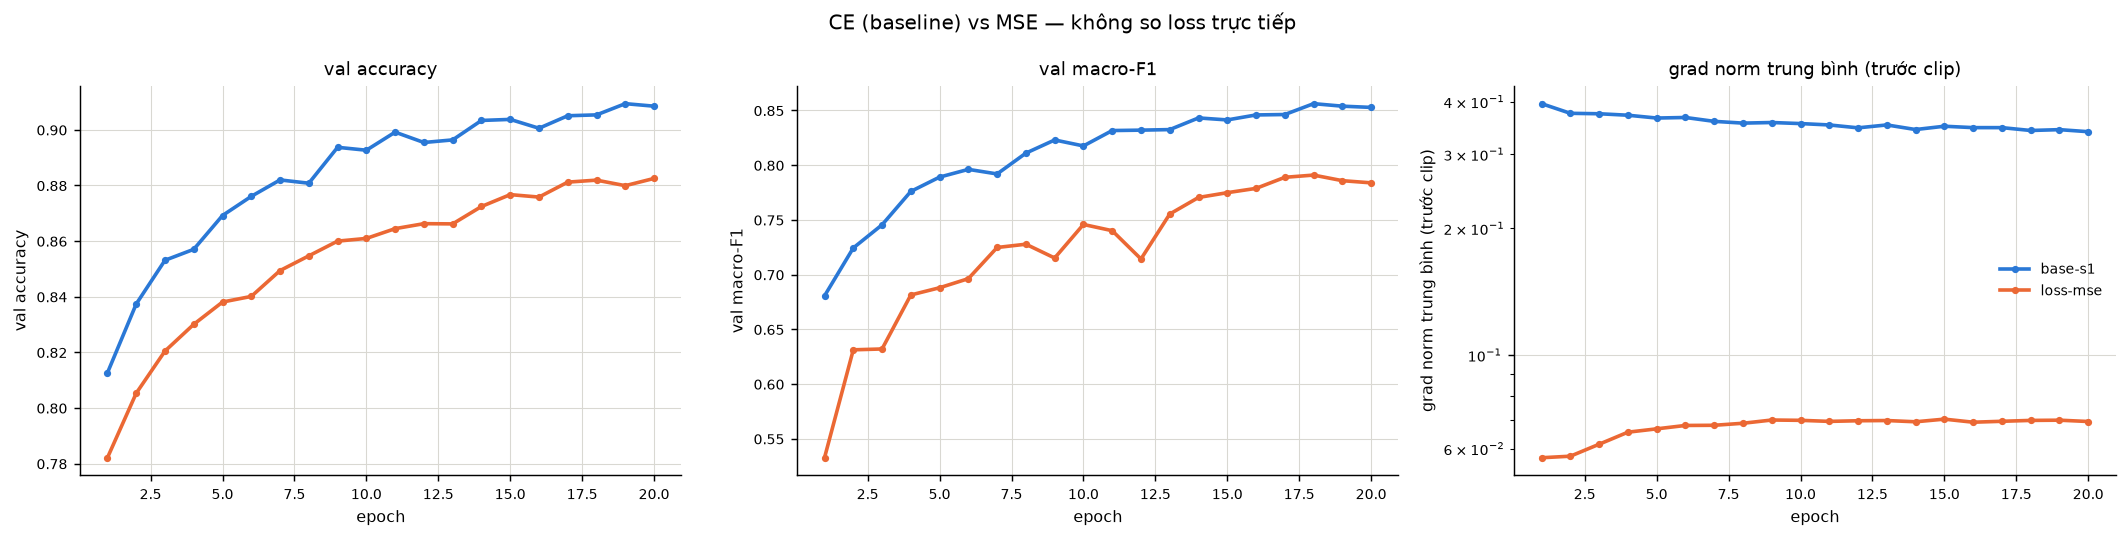

In [10]:
run(exp_id="loss-mse", group="loss", loss="mse", description="MSE trên logit vs one-hot (trung bình trên B×7) thay cho CE",
    note="lr giữ nguyên của baseline (chỉnh cho CE), chưa chỉnh riêng cho MSE")
plot_compare([RESULTS["base-s1"], RESULTS["loss-mse"]], ["val_acc", "val_macro_f1", "grad_norm"],
             f"{OUT_DIR}/figures/compare_loss.png", title="CE (baseline) vs MSE — không so loss trực tiếp")
compare(["base-s1", "loss-mse"], extra=("loss",)); show("compare_loss")

**Đối chiếu sau khi chạy.** Khớp dự đoán. `loss-mse` đạt val macro-F1 0.7839, thấp hơn trung bình baseline 0.0701 (vượt 2σ = 0.0234); accuracy 0.8825 so với 0.9094 của `base-s1`. Chuẩn gradient trung bình của MSE là 0.068, nhỏ hơn CE (0.357) khoảng 5 lần, và MSE chậm hơn ngay từ đầu (macro-F1 sau epoch 1: 0.533 so với 0.681). Cơ chế: gradient của MSE theo logit là `2(z − onehot)/7`, bị chia cho số lớp và tỉ lệ tuyến tính với sai số, trong khi CE cho `softmax − onehot` không bị chia và lớn khi sai nặng. Macro-F1 tụt nhiều hơn accuracy (−0.070 so với −0.027), tức là lớp hiếm thiệt nhất. Hạn chế: lr = 0.3 được chỉnh cho CE; MSE có thể cần lr lớn hơn, nên một phần khoảng cách là do bước hiệu dụng nhỏ.

### Chủ đề 2 — Bộ tối ưu hoá (`opt-…`)
Mỗi bộ tối ưu được thử 3 lr cách nhau ~3 lần, rồi so **ở lr tốt nhất của từng bộ** (theo val macro-F1). SGD+momentum đã có 4 lr từ lưới ở Part 2. AdamW dùng `weight_decay=0.01`; thêm một lần AdamW với `weight_decay=0` để kiểm chứng nó trùng Adam.

**Dự đoán trước.**
- SGD thuần cần lr lớn hơn SGD+momentum khoảng 10 lần để đi cùng quãng đường (momentum 0,9 khuếch đại bước hiệu dụng ~1/(1−0,9) = 10 lần); ở cùng 20 epoch, SGD thuần với lr nhỏ sẽ chưa hội tụ.
- Adam/AdamW chia bước theo độ lớn gradient của từng tham số, nên hội tụ nhanh hơn ở các epoch đầu và ít nhạy với lr hơn; lr tốt nhất quanh 1e-3 đến 3e-3. Ở lr tốt nhất của mỗi bộ, Adam nhỉnh hơn SGD+momentum trong 20 epoch.
- AdamW (wd = 0,01) gần như trùng Adam: mô hình nhỏ so với 372 nghìn mẫu, chưa quá khớp, nên suy giảm trọng số ít tác dụng. AdamW với wd = 0 phải cho kết quả giống hệt Adam.

In [11]:
OPT_GRID = {"sgd": [0.03, 0.1, 0.3], "adam": [3e-4, 1e-3, 3e-3], "adamw": [3e-4, 1e-3, 3e-3]}
for name, lrs in OPT_GRID.items():
    for lr in lrs:
        wd = 0.01 if name == "adamw" else 0.0
        run(exp_id=f"opt-{name}-lr{lr:g}", group="optimizer", optimizer=name, lr=lr, weight_decay=wd,
            description=f"{name} lr={lr:g}" + (", weight_decay=0.01" if wd else ""),
            note="đổi bộ tối ưu và lr (mỗi bộ thử 3 lr, so ở lr tốt nhất)" + ("; AdamW kèm weight_decay=0.01" if wd else ""))
run(exp_id="opt-adamw-wd0-lr0.001", group="optimizer", optimizer="adamw", lr=1e-3, weight_decay=0.0,
    description="AdamW weight_decay=0, lr=1e-3 (kiểm chứng trùng Adam)", note="so với opt-adam-lr0.001")

opt-sgd-lr0.03           val loss 0.4308 @ep18 | acc 0.8203 | macro-F1 0.6646 | 0.57s/epoch


opt-sgd-lr0.1            val loss 0.3485 @ep18 | acc 0.8537 | macro-F1 0.7421 | 0.56s/epoch


opt-sgd-lr0.3            val loss 0.2950 @ep16 | acc 0.8773 | macro-F1 0.7946 | 0.55s/epoch


opt-adam-lr0.0003        val loss 0.3084 @ep20 | acc 0.8760 | macro-F1 0.7941 | 0.77s/epoch


opt-adam-lr0.001         val loss 0.2430 @ep18 | acc 0.9038 | macro-F1 0.8433 | 0.82s/epoch


...

opt-adamw-lr0.0003       val loss 0.3110 @ep20 | acc 0.8749 | macro-F1 0.7921 | 0.79s/epoch


opt-adamw-lr0.001        val loss 0.2483 @ep18 | acc 0.9006 | macro-F1 0.8415 | 0.79s/epoch


opt-adamw-lr0.003        val loss 0.2155 @ep20 | acc 0.9135 | macro-F1 0.8748 | 0.80s/epoch


opt-adamw-wd0-lr0.001    val loss 0.2430 @ep18 | acc 0.9038 | macro-F1 0.8433 | 0.84s/epoch


{'cfg': {'exp_id': 'opt-adamw-wd0-lr0.001',
  'group': 'optimizer',
  'description': 'AdamW weight_decay=0, lr=1e-3 (kiểm chứng trùng Adam)',
  'loss': 'ce',
  'optimizer': 'adamw',
  'lr': 0.001,
  'weight_decay': 0.0,
  'momentum': 0.9,
  'batch': 512,
  'epochs': 20,
  'hidden': (256, 128),
  'dropout': 0.0,
  'init': 'he',
  'clip_norm': None,
  'precision': 'fp32',
  'scheduler': None,
  'seed': 1},
 'history': {'epoch': [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20],
  'train_loss': [0.4854692775082057,
   0.41861810430222307,
   0.38122152411643767,
   0.3608530291571744,
   0.33434499432688375,
   0.3338936506007091,
   0.3023630826005891,
   0.2906395362507442,
   0.2807217367479938,
   0.27593003536232646,
   0.26596176199616584,
   0.2601441878391642,
   0.2566610247765294,
   0.24521190543790103,
   0.2536075874783303,
   0.24963305404129588,
   0.23649767393988236,
   0.2230979563802661,
   0

Mỗi bộ tối ưu ở lr tốt nhất của nó:


,optimizer,lr,best_val_loss,best_epoch,val_acc,val_macro_f1,Δf1 vs base,vượt 2σ?,val−train loss,s/epoch,diverged
exp_id,,,,,,,,,,,
opt-sgd-lr0.3,sgd,0.300,0.2950,16,0.8773,0.7946,-0.0594,Có,0.0159,0.5546,False
base-s1,sgd_momentum,0.300,0.2276,19,0.9094,0.8539,-0.0000,Không,0.0269,0.5814,False
opt-adam-lr0.003,adam,0.003,0.2093,20,0.9161,0.8789,0.0249,Có,0.0280,0.7877,False
opt-adamw-lr0.003,adamw,0.003,0.2155,20,0.9135,0.8748,0.0209,Không,0.0230,0.7952,False


Mọi lần chạy của nhóm:


,optimizer,lr,weight_decay,best_val_loss,best_epoch,val_acc,val_macro_f1,Δf1 vs base,vượt 2σ?,val−train loss,s/epoch,diverged
exp_id,,,,,,,,,,,,
opt-sgd-lr0.03,sgd,0.0300,0.00,0.4308,18,0.8203,0.6646,-0.1893,Có,0.0063,0.5724,False
opt-sgd-lr0.1,sgd,0.1000,0.00,0.3485,18,0.8537,0.7421,-0.1119,Có,0.0096,0.5578,False
opt-sgd-lr0.3,sgd,0.3000,0.00,0.2950,16,0.8773,0.7946,-0.0594,Có,0.0159,0.5546,False
base-s1,sgd_momentum,0.3000,0.00,0.2276,19,0.9094,0.8539,-0.0000,Không,0.0269,0.5814,False
hp-lr0.01,sgd_momentum,0.0100,0.00,0.3167,19,0.8714,0.7623,-0.0917,Có,0.0106,0.6220,False
hp-lr0.03,sgd_momentum,0.0300,0.00,0.2651,20,0.8925,0.8245,-0.0295,Có,0.0178,0.5995,False
hp-lr0.1,sgd_momentum,0.1000,0.00,0.2379,20,0.9043,0.8537,-0.0003,Không,0.0250,0.5563,False
opt-adam-lr0.0003,adam,0.0003,0.00,0.3084,20,0.8760,0.7941,-0.0599,Có,0.0118,0.7742,False
opt-adam-lr0.001,adam,0.0010,0.00,0.2430,18,0.9038,0.8433,-0.0107,Không,0.0207,0.8153,False


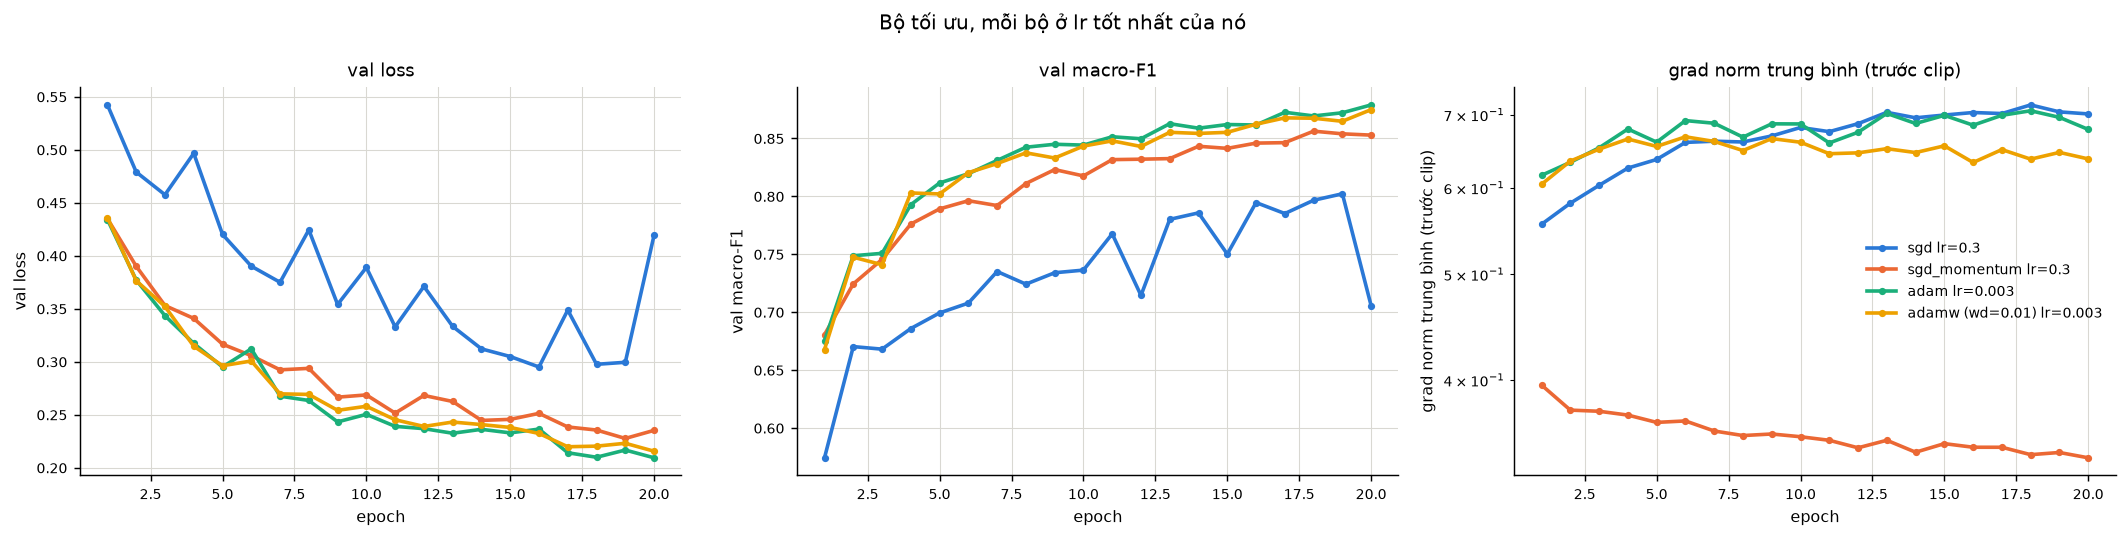

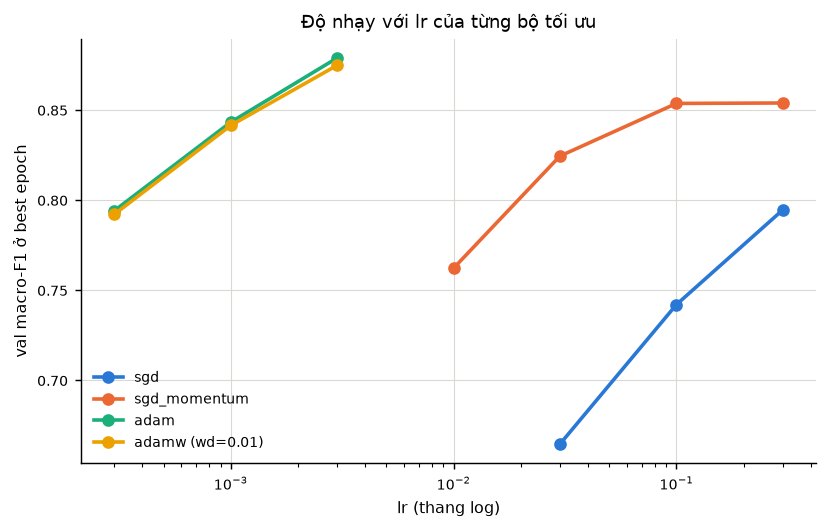

Adam vs AdamW(wd=0), lr=1e-3: chênh val loss lớn nhất qua các epoch = 0.0


In [12]:
SGDM_IDS = ["base-s1"] + [f"hp-lr{lr:g}" for lr in LR_GRID if lr != BASE_LR]
OPT_RUNS = {"sgd": [f"opt-sgd-lr{lr:g}" for lr in OPT_GRID["sgd"]],
            "sgd_momentum": SGDM_IDS,
            "adam": [f"opt-adam-lr{lr:g}" for lr in OPT_GRID["adam"]],
            "adamw (wd=0.01)": [f"opt-adamw-lr{lr:g}" for lr in OPT_GRID["adamw"]]}
BEST_OPT = {name: max(ids, key=f1_of) for name, ids in OPT_RUNS.items()}   # lr tốt nhất của từng bộ, theo val

print("Mỗi bộ tối ưu ở lr tốt nhất của nó:")
compare(list(BEST_OPT.values()), extra=("optimizer", "lr"))
print("Mọi lần chạy của nhóm:")
compare([i for ids in OPT_RUNS.values() for i in ids] + ["opt-adamw-wd0-lr0.001"], extra=("optimizer", "lr", "weight_decay"))

plot_compare([RESULTS[i] for i in BEST_OPT.values()], ["val_loss", "val_macro_f1", "grad_norm"], f"{OUT_DIR}/figures/compare_optimizer.png",
             title="Bộ tối ưu, mỗi bộ ở lr tốt nhất của nó", labels=[f"{n} lr={RESULTS[i]['cfg']['lr']:g}" for n, i in BEST_OPT.items()])
plot_lr_sweep({n: [RESULTS[i] for i in ids] for n, ids in OPT_RUNS.items()}, f"{OUT_DIR}/figures/compare_optimizer_lr.png")
show("compare_optimizer"); show("compare_optimizer_lr")

a, w = RESULTS["opt-adam-lr0.001"]["history"]["val_loss"], RESULTS["opt-adamw-wd0-lr0.001"]["history"]["val_loss"]
print("Adam vs AdamW(wd=0), lr=1e-3: chênh val loss lớn nhất qua các epoch =", max(abs(x - y) for x, y in zip(a, w)))

**Đối chiếu sau khi chạy.**

| Bộ tối ưu | lr tốt nhất | exp_id | val macro-F1 | Δ so với TB baseline | vượt 2σ? |
|---|---|---|---|---|---|
| SGD | 0.3 | `opt-sgd-lr0.3` | 0.7946 | −0.0594 | Có |
| SGD + momentum | 0.3 | `base-s1` | 0.8539 | 0 | — |
| Adam | 0.003 | `opt-adam-lr0.003` | 0.8789 | +0.0249 | Có (sát ngưỡng) |
| AdamW (wd 0.01) | 0.003 | `opt-adamw-lr0.003` | 0.8748 | +0.0209 | Không |

- **Adam nhỉnh hơn SGD+momentum** ở lr tốt nhất của mỗi bộ: +0.0249, chỉ vừa qua ngưỡng 2σ = 0.0234, nên đây là bằng chứng yếu (1 seed cho Adam). AdamW thấp hơn Adam 0.004, nằm trong nhiễu: weight decay 0.01 không tạo khác biệt đo được. SGD thuần thua rõ (−0.059): không có momentum thì với cùng lr, quãng đường đi được trong 20 epoch ngắn hơn nhiều; val loss của nó còn dao động mạnh ở cuối (best 0.295 ở epoch 16, epoch cuối 0.419).
- **Độ nhạy lr (`compare_optimizer_lr.png`):** mọi bộ đều tăng đơn điệu theo lr trong lưới. Đổi lr 10 lần làm macro-F1 đổi 0.085 (Adam: 0.7941 → 0.8789), 0.092 (SGD+momentum: 0.7623 → 0.8539 qua 30 lần), 0.130 (SGD). Khác dự đoán: Adam **không** ít nhạy lr hơn rõ rệt trong 20 epoch.
- **Nếu không chỉnh lr:** ở lr = 0.001, Adam (0.8433) thua baseline SGD+momentum lr 0.3 (0.8539); ở lr = 0.03, SGD thuần chỉ đạt 0.6646. Thứ hạng giữa các bộ tối ưu đảo được chỉ bằng cách chọn lr, nên so sánh ở một lr duy nhất là so sánh lr chứ không phải bộ tối ưu.
- **Hạn chế:** lr tốt nhất của cả 4 bộ đều ở mép trên của lưới, nên lr tối ưu thật có thể còn cao hơn và thứ hạng Adam/SGD+momentum chưa chắc chắn.
- **Adam và AdamW(wd = 0):** chênh val loss lớn nhất qua 20 epoch = 0.0, trùng nhau hoàn toàn, đúng công thức.

### Chủ đề 3 — Hyper-parameter (`hp-…`)
Đổi lần lượt: batch (128 / 2048), batch 2048 kèm lr × 4 (quy tắc tăng lr theo lô), độ rộng (`M-wide`), độ sâu (`M-deep`), weight decay, số epoch (40). Các lần `hp-lr…` (đổi lr) đã chạy ở Part 2.

**Dự đoán trước.**
- **Batch.** Cùng 20 epoch nhưng số bước cập nhật khác nhau: batch 128 có 4 lần số bước của 512 (≈ 58 nghìn so với ≈ 14,5 nghìn), batch 2048 chỉ có 1/4 (≈ 3,6 nghìn). Mô hình còn đang học ở epoch 20, nên batch 128 sẽ đạt F1 cao hơn (nhiều bước hơn, đổi lại chậm hơn mỗi epoch), batch 2048 với cùng lr sẽ thấp hơn. Batch 2048 với lr × 4 sẽ lấy lại phần lớn khoảng cách vì quãng đường mỗi epoch tương đương batch 512, nếu lr × 4 chưa gây mất ổn định.
- **Độ rộng / độ sâu.** `M-wide` (161 nghìn tham số) sẽ tốt hơn rõ vì baseline đang chưa khớp hết; `M-deep` chỉ thêm 8 nghìn tham số nên cải thiện ít hơn.
- **Weight decay 1e-4.** Gần như không đổi hoặc hơi kém: mô hình chưa quá khớp.
- **40 epoch.** Tốt hơn 20 epoch nếu `best_epoch` của baseline là epoch cuối.
- **lr (từ Part 2).** lr quá nhỏ: hội tụ chậm; lr quá lớn: dao động hoặc kém ổn định.

hp-batch128              val loss 0.3135 @ep16 | acc 0.8777 | macro-F1 0.7970 | 2.16s/epoch


hp-batch2048             val loss 0.2427 @ep18 | acc 0.9030 | macro-F1 0.8370 | 0.20s/epoch


hp-batch2048-lrx4        val loss 0.3655 @ep18 | acc 0.8485 | macro-F1 0.6224 | 0.20s/epoch


hp-wide                  val loss 0.1906 @ep20 | acc 0.9240 | macro-F1 0.8776 | 0.84s/epoch


hp-deep                  val loss 0.2175 @ep20 | acc 0.9132 | macro-F1 0.8433 | 0.74s/epoch


hp-wd1e-4                val loss 0.2857 @ep18 | acc 0.8829 | macro-F1 0.8108 | 0.75s/epoch


hp-ep40                  val loss 0.2044 @ep35 | acc 0.9215 | macro-F1 0.8676 | 0.68s/epoch


,lr,batch,hidden,weight_decay,epochs,best_val_loss,best_epoch,val_acc,val_macro_f1,Δf1 vs base,vượt 2σ?,val−train loss,s/epoch,diverged
exp_id,,,,,,,,,,,,,,
base-s1,0.30,512,"(256, 128)",0.0000,20,0.2276,19,0.9094,0.8539,-0.0000,Không,0.0269,0.5814,False
hp-lr0.01,0.01,512,"(256, 128)",0.0000,20,0.3167,19,0.8714,0.7623,-0.0917,Có,0.0106,0.6220,False
hp-lr0.03,0.03,512,"(256, 128)",0.0000,20,0.2651,20,0.8925,0.8245,-0.0295,Có,0.0178,0.5995,False
hp-lr0.1,0.10,512,"(256, 128)",0.0000,20,0.2379,20,0.9043,0.8537,-0.0003,Không,0.0250,0.5563,False
hp-batch128,0.30,128,"(256, 128)",0.0000,20,0.3135,16,0.8777,0.7970,-0.0570,Có,0.0209,2.1585,False
hp-batch2048,0.30,2048,"(256, 128)",0.0000,20,0.2427,18,0.9030,0.8370,-0.0169,Không,0.0218,0.2007,False
hp-batch2048-lrx4,1.20,2048,"(256, 128)",0.0000,20,0.3655,18,0.8485,0.6224,-0.2316,Có,0.0097,0.2019,False
hp-wide,0.30,512,"(512, 256)",0.0000,20,0.1906,20,0.9240,0.8776,0.0236,Có,0.0330,0.8411,False
hp-deep,0.30,512,"(256, 128, 64)",0.0000,20,0.2175,20,0.9132,0.8433,-0.0106,Không,0.0233,0.7368,False


số bước cập nhật mỗi epoch: {'hp-batch128': 2906, 'base-s1': 727, 'hp-batch2048': 182}


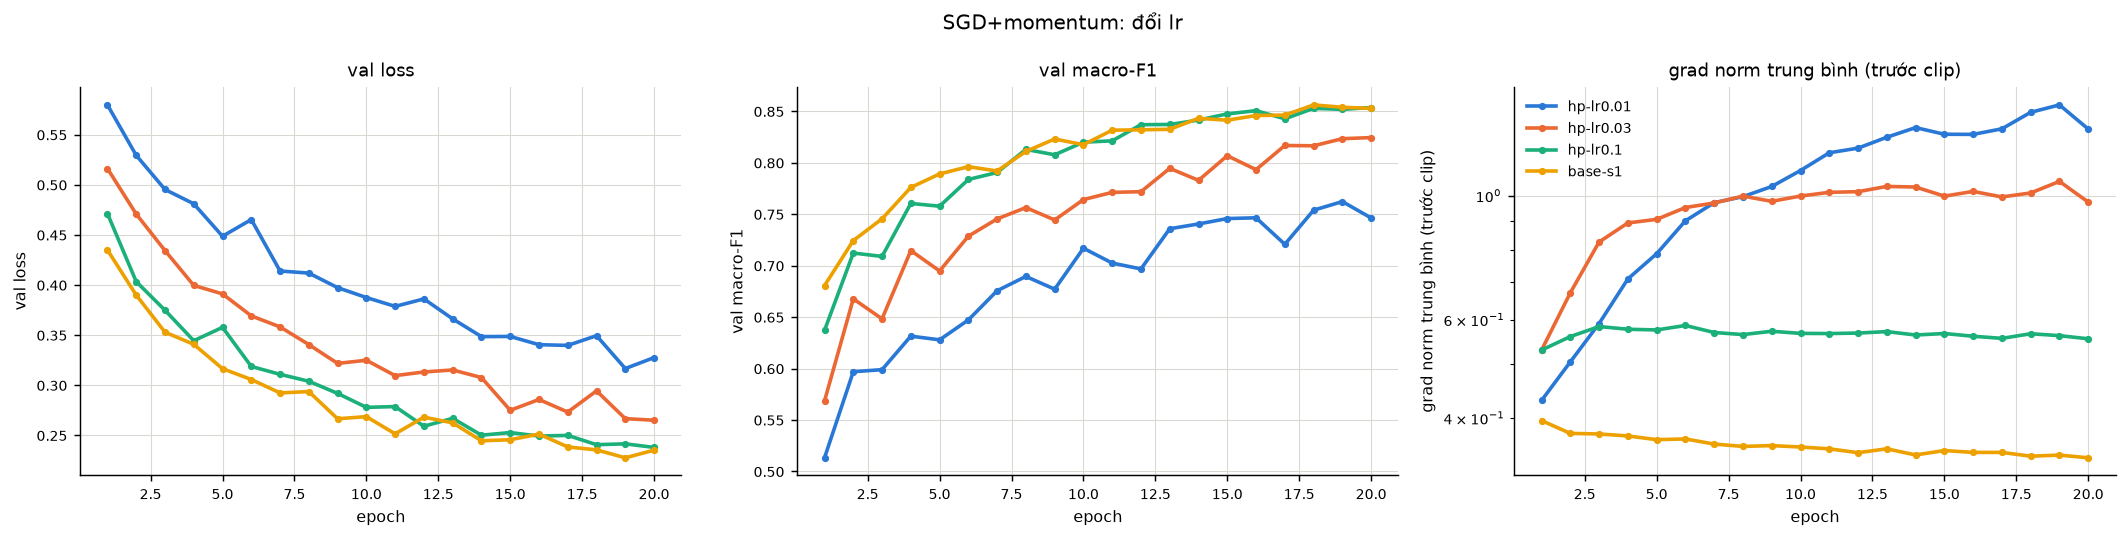

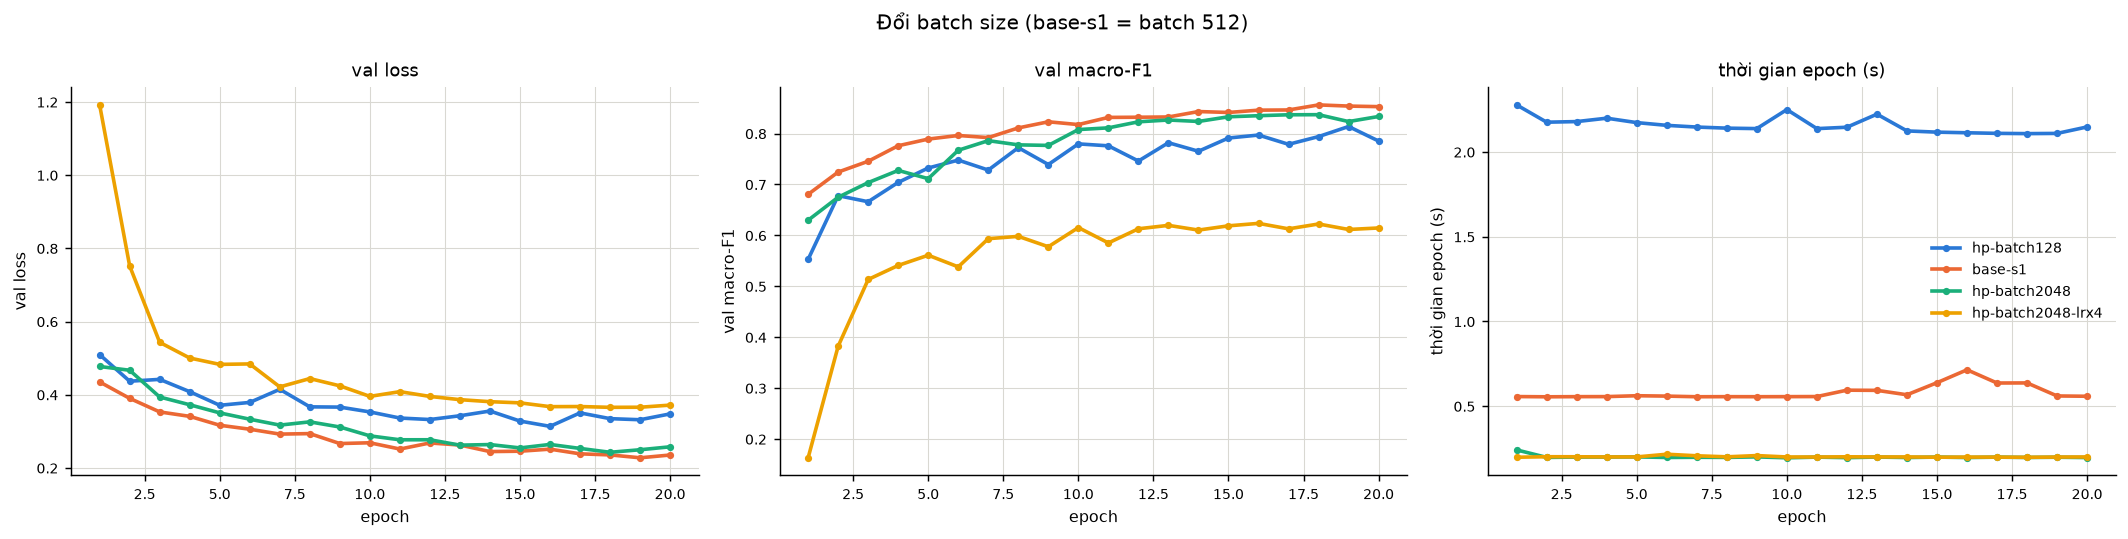

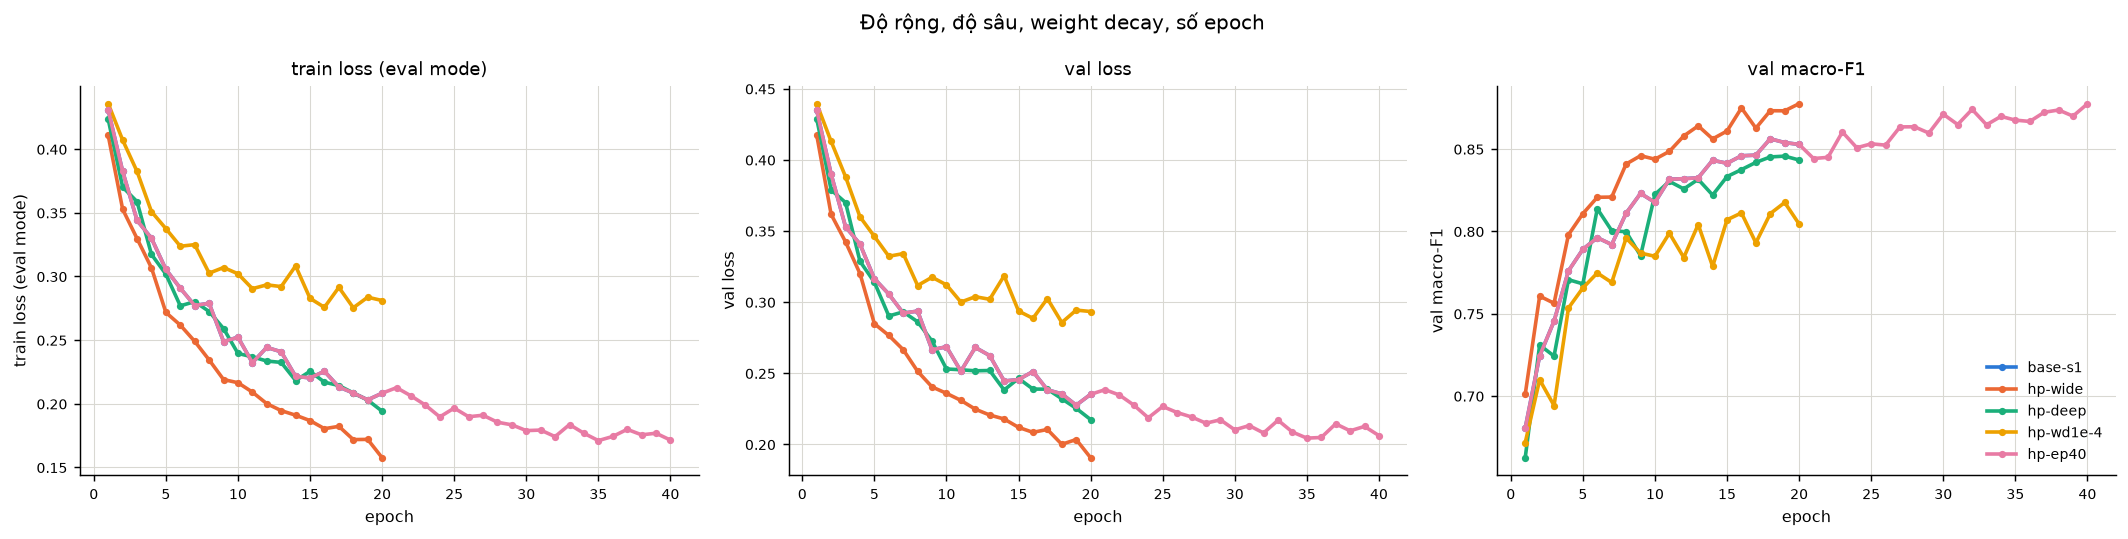

In [13]:
run(exp_id="hp-batch128", group="hparam", batch=128, description="batch 128 (4x số bước cập nhật mỗi epoch)")
run(exp_id="hp-batch2048", group="hparam", batch=2048, description="batch 2048 (1/4 số bước cập nhật mỗi epoch), lr giữ nguyên")
run(exp_id="hp-batch2048-lrx4", group="hparam", batch=2048, lr=4 * BASE_LR,
    description=f"batch 2048 và lr x4 = {4 * BASE_LR:g} (quy tắc tăng lr theo lô)", note="đổi HAI yếu tố (batch và lr), không có khởi động lr")
run(exp_id="hp-wide", group="hparam", hidden=(512, 256), description="M-wide 54-512-256-7 (161 287 tham số)")
run(exp_id="hp-deep", group="hparam", hidden=(256, 128, 64), description="M-deep 54-256-128-64-7 (55 687 tham số)")
run(exp_id="hp-wd1e-4", group="hparam", weight_decay=1e-4, description="weight_decay=1e-4 (L2 trong SGD)")
run(exp_id="hp-ep40", group="hparam", epochs=40, description="40 epoch thay vì 20", note="khác số epoch so với baseline (đây là yếu tố đang thử)")

HP_LR_IDS = [f"hp-lr{lr:g}" for lr in LR_GRID if lr != BASE_LR]
compare(["base-s1"] + HP_LR_IDS + ["hp-batch128", "hp-batch2048", "hp-batch2048-lrx4", "hp-wide", "hp-deep", "hp-wd1e-4", "hp-ep40"],
        extra=("lr", "batch", "hidden", "weight_decay", "epochs"))
print("số bước cập nhật mỗi epoch:", {i: RESULTS[i]["summary"]["steps_per_epoch"] for i in ("hp-batch128", "base-s1", "hp-batch2048")})

plot_compare([RESULTS[i] for i in sorted(SGDM_IDS, key=lambda i: RESULTS[i]["cfg"]["lr"])], ["val_loss", "val_macro_f1", "grad_norm"],
             f"{OUT_DIR}/figures/compare_hparam_lr.png", title="SGD+momentum: đổi lr")
plot_compare([RESULTS[i] for i in ("hp-batch128", "base-s1", "hp-batch2048", "hp-batch2048-lrx4")], ["val_loss", "val_macro_f1", "epoch_time_s"],
             f"{OUT_DIR}/figures/compare_hparam_batch.png", title="Đổi batch size (base-s1 = batch 512)")
plot_compare([RESULTS[i] for i in ("base-s1", "hp-wide", "hp-deep", "hp-wd1e-4", "hp-ep40")], ["train_loss", "val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_hparam_capacity.png", title="Độ rộng, độ sâu, weight decay, số epoch")
show("compare_hparam_lr"); show("compare_hparam_batch"); show("compare_hparam_capacity")

**Đối chiếu sau khi chạy.**
- **Batch 128: khác dự đoán.** `hp-batch128` đạt 0.7970, **thấp hơn** baseline 0.0570 (vượt 2σ) dù có gấp 4 số bước (2 906 so với 727 bước/epoch) và chậm gấp ~3.7 lần (2.16 s so với 0.58 s/epoch). Lý do: dự đoán bỏ qua việc lr = 0.3 được chọn cho batch 512. Nhiễu của SGD tỉ lệ với lr/batch; giữ lr mà giảm batch 4 lần thì nhiễu tăng 4 lần, tương đương chạy batch 512 với lr ≈ 1.2, quá cao. Val loss của lần này dao động và tốt nhất ở epoch 16 chứ không phải cuối.
- **Batch 2048:** 0.8370 (Δ −0.0169, **không** vượt 2σ) với 1/4 số bước và 0.20 s/epoch (nhanh hơn ~2.9 lần). Chưa kết luận được là kém hơn.
- **Batch 2048 + lr × 4 (lr = 1.2): khác dự đoán.** 0.6224 (Δ −0.2316), chuẩn gradient có gai tới 14.8. Quy tắc tăng lr theo lô không áp dụng được khi lr gốc đã sát mép ổn định, và ở đây không có giai đoạn khởi động lr.
- **Độ rộng / độ sâu:** `hp-wide` 0.8776 (Δ +0.0236, chỉ vừa qua 2σ) và val loss thấp hơn rõ (0.1906 so với 0.2276); `hp-deep` 0.8433 (Δ −0.0106, trong nhiễu). Thêm bề rộng có ích hơn thêm một lớp 64 nơ-ron.
- **Weight decay 1e-4:** 0.8108 (Δ −0.0432, vượt 2σ): **có hại**. Mô hình đang chưa khớp hết; kéo trọng số về 0 làm giảm năng lực (train loss cuối 0.281 so với 0.208 của baseline).
- **40 epoch:** 0.8676 (Δ +0.0136, **không** vượt 2σ), best epoch 35. Val loss có giảm (0.2044 so với 0.2276) nhưng macro-F1 chưa đủ bằng chứng, nên cấu hình cuối không dùng 40 epoch.
- **lr:** lr nhỏ hội tụ chậm rõ (0.01: 0.7623; 0.03: 0.8245), đều vượt 2σ; 0.1 và 0.3 tương đương.

### Chủ đề 4 — Dropout (`drop-…`)
**Dự đoán trước.** Dropout là thuốc cho quá khớp. Baseline có khoảng cách val − train nhỏ và vẫn đang giảm ở epoch cuối, tức chưa quá khớp, nên dropout sẽ **không giúp**: q = 0,1 gần như không đổi (trong nhiễu), q = 0,3 và 0,5 làm giảm năng lực hiệu dụng của một mạng vốn đã nhỏ nên val macro-F1 **giảm** dần theo q. Khoảng cách val − train sẽ thu hẹp (thậm chí âm). Train loss được đo ở `eval()` nên so được với val.

drop-0.1                 val loss 0.2450 @ep20 | acc 0.9016 | macro-F1 0.8309 | 0.66s/epoch


drop-0.3                 val loss 0.3151 @ep20 | acc 0.8695 | macro-F1 0.7750 | 0.62s/epoch


drop-0.5                 val loss 0.4202 @ep20 | acc 0.8231 | macro-F1 0.6574 | 0.60s/epoch


,dropout,best_val_loss,best_epoch,val_acc,val_macro_f1,Δf1 vs base,vượt 2σ?,val−train loss,s/epoch,diverged
exp_id,,,,,,,,,,
base-s1,0.0,0.2276,19,0.9094,0.8539,-0.0000,Không,0.0269,0.5814,False
drop-0.1,0.1,0.2450,20,0.9016,0.8309,-0.0231,Không,0.0146,0.6611,False
drop-0.3,0.3,0.3151,20,0.8695,0.7750,-0.0790,Có,0.0073,0.6186,False
drop-0.5,0.5,0.4202,20,0.8231,0.6574,-0.1965,Có,0.0041,0.6010,False


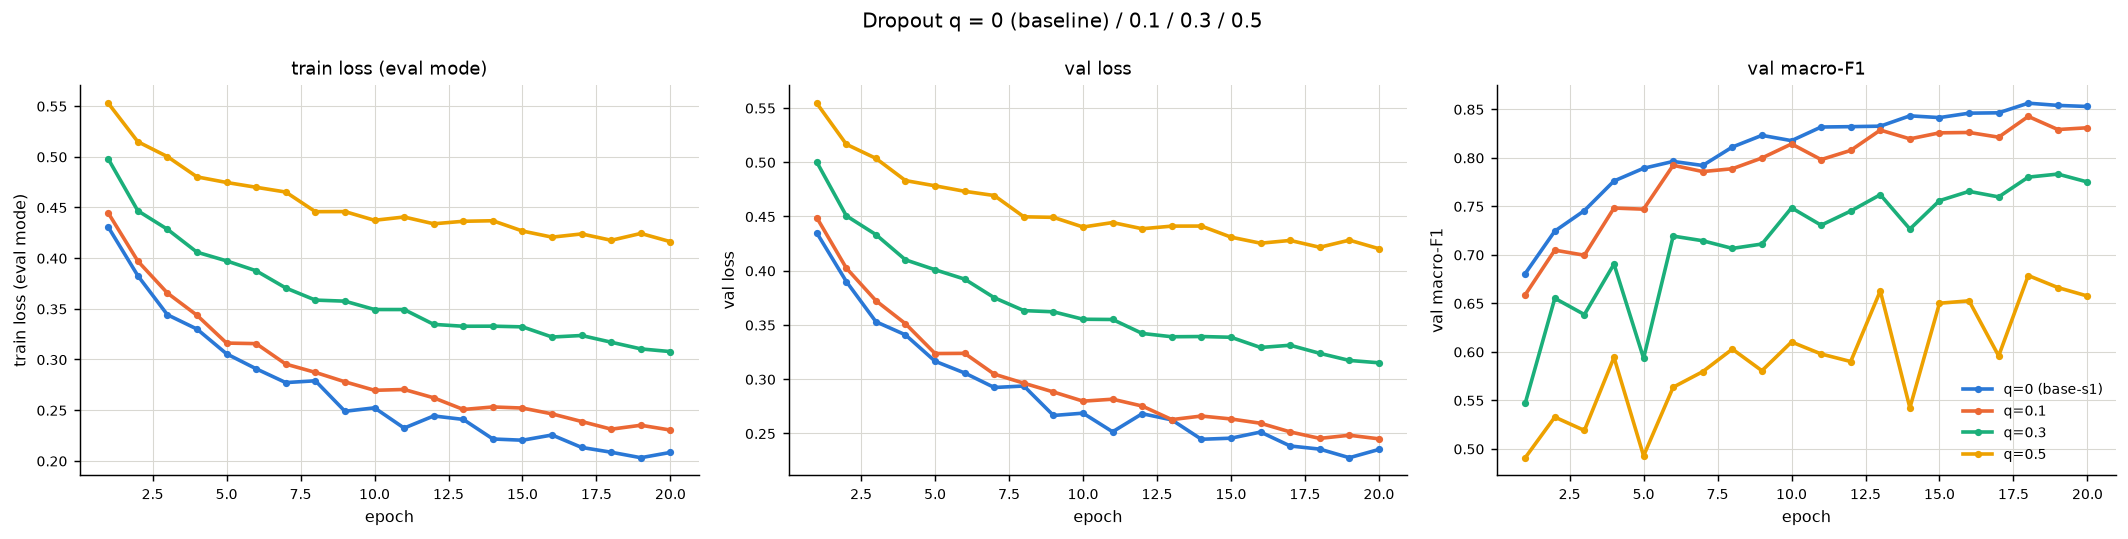

In [14]:
DROP_IDS = []
for q in (0.1, 0.3, 0.5):
    DROP_IDS.append(run(exp_id=f"drop-{q:g}", group="dropout", dropout=q, description=f"dropout q={q:g} sau ReLU của hai lớp ẩn")["cfg"]["exp_id"])
compare(["base-s1"] + DROP_IDS, extra=("dropout",))
plot_compare([RESULTS[i] for i in ["base-s1"] + DROP_IDS], ["train_loss", "val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_dropout.png", title="Dropout q = 0 (baseline) / 0.1 / 0.3 / 0.5", labels=["q=0 (base-s1)", "q=0.1", "q=0.3", "q=0.5"])
show("compare_dropout")

**Đối chiếu sau khi chạy.** Khớp dự đoán về hướng. Val macro-F1 giảm đơn điệu theo q: 0.8309 (q = 0.1, Δ −0.0231, sát nhưng chưa vượt 2σ = 0.0234), 0.7750 (q = 0.3, Δ −0.0790), 0.6574 (q = 0.5, Δ −0.1965). Khoảng cách val − train loss thu hẹp đúng như kỳ vọng: 0.027 (q = 0) → 0.015 → 0.007 → 0.004, nhưng thu hẹp vì **train loss tăng** (0.208 → 0.230 → 0.308 → 0.416), không phải vì val loss giảm. Mức giảm ở q = 0.1 lớn hơn tôi nghĩ ("gần như không đổi"). Kết luận: mô hình chưa quá khớp (khoảng cách chỉ 0.027) nên dropout chỉ lấy bớt năng lực của một mạng 48 nghìn tham số; nó chỉ đáng dùng khi train loss thấp hơn val loss rõ rệt.

### Chủ đề 5 — Cắt gradient (`clip-…`)
Ngưỡng `c` chọn từ `grad_norm` của baseline: lấy **một nửa trung vị** của chuẩn gradient trung bình theo epoch, để clipping thực sự kích hoạt ở phần lớn các bước (nếu `c` lớn hơn mọi `grad_norm` thì clipping không làm gì). Ba lần chạy:
1. `clip-normal`: lr baseline, có clip.
2. `clip-highlr-noclip`: lr × 10, không clip (phản chứng).
3. `clip-highlr`: lr × 10, có clip với cùng `c`.

**Dự đoán trước.**
- Ở lr bình thường, clipping với `c` nhỏ hơn chuẩn gradient điển hình hoạt động như **giảm lr hiệu dụng** (mỗi bước bị co lại theo tỉ lệ c/‖g‖), nên hội tụ chậm hơn một chút và F1 hơi thấp hơn hoặc ngang baseline; không có lợi vì baseline không có gai gradient.
- Ở lr × 10, không clip: bước cập nhật quá lớn, loss dao động mạnh, có thể thành NaN hoặc kẹt ở mức loss cao (nơ-ron ReLU chết sau một bước quá đà); `grad_norm_max` sẽ có gai lớn. Có clip: mỗi bước dài tối đa lr·c nên huấn luyện ổn định trở lại và đạt F1 tốt hơn hẳn lần không clip.

grad_norm baseline (trung bình theo epoch): min 0.339, trung vị 0.354, max 0.396; bước lớn nhất 2.871
-> chọn c = 0.18; lr cao = 3



clip-normal              val loss 0.2381 @ep18 | acc 0.9047 | macro-F1 0.8516 | 0.57s/epoch


clip-highlr-noclip       val loss 1.2072 @ep19 | acc 0.4876 | macro-F1 0.0936 | 0.57s/epoch


clip-highlr              val loss 0.6459 @ep15 | acc 0.7327 | macro-F1 0.4494 | 0.57s/epoch


,lr,clip_norm,best_val_loss,best_epoch,val_acc,val_macro_f1,Δf1 vs base,vượt 2σ?,val−train loss,s/epoch,diverged
exp_id,,,,,,,,,,,
base-s1,0.3,NaN,0.2276,19,0.9094,0.8539,-0.0000,Không,0.0269,0.5814,False
clip-normal,0.3,0.18,0.2381,18,0.9047,0.8516,-0.0024,Không,0.0213,0.5747,False
clip-highlr-noclip,3.0,NaN,1.2072,19,0.4876,0.0936,-0.7603,Có,0.0000,0.5700,False
clip-highlr,3.0,0.18,0.6459,15,0.7327,0.4494,-0.4046,Có,0.0034,0.5697,False


clip-normal          tỉ lệ bước bị clip: 100.00% | grad_norm trung bình 0.613 | gai lớn nhất 2.87
clip-highlr-noclip   tỉ lệ bước bị clip: 0.00% | grad_norm trung bình 0.100 | gai lớn nhất 164
clip-highlr          tỉ lệ bước bị clip: 85.42% | grad_norm trung bình 0.270 | gai lớn nhất 3.34


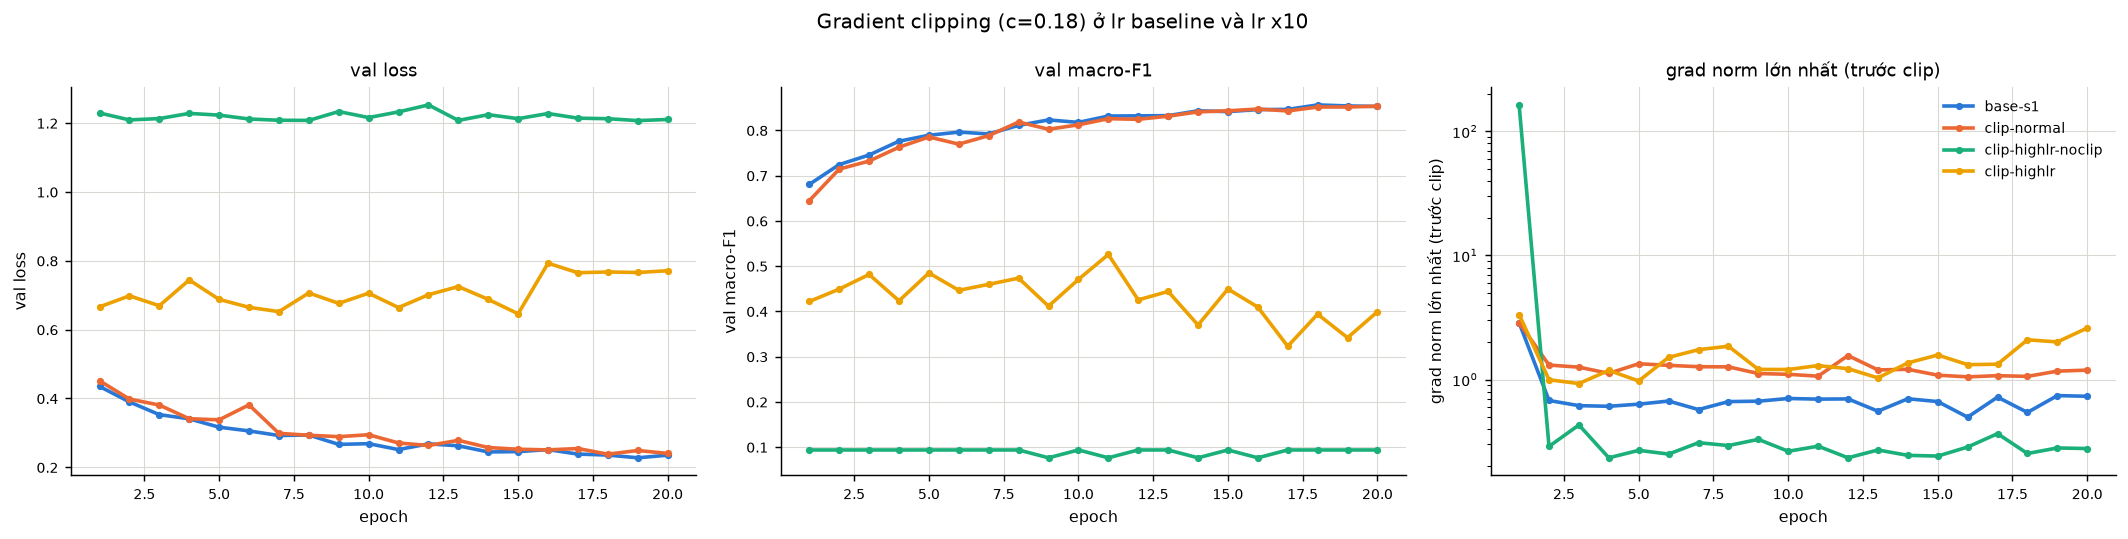

In [15]:
base_gn = RESULTS["base-s1"]["history"]["grad_norm"]
CLIP_C = float(f"{0.5 * np.median(base_gn):.2g}")
HIGH_LR = 10 * BASE_LR
print(f"grad_norm baseline (trung bình theo epoch): min {min(base_gn):.3f}, trung vị {np.median(base_gn):.3f}, max {max(base_gn):.3f}; "
      f"bước lớn nhất {max(RESULTS['base-s1']['history']['grad_norm_max']):.3f}")
print(f"-> chọn c = {CLIP_C:g}; lr cao = {HIGH_LR:g}\n")

run(exp_id="clip-normal", group="clipping", clip_norm=CLIP_C, description=f"clip c={CLIP_C:g} ở lr baseline",
    note=f"c = 0.5 x trung vị grad_norm của base-s1")
run(exp_id="clip-highlr-noclip", group="clipping", lr=HIGH_LR, description=f"lr x10 = {HIGH_LR:g}, không clip (phản chứng)",
    note="đối chứng cho clip-highlr: chỉ đổi lr so với baseline")
run(exp_id="clip-highlr", group="clipping", lr=HIGH_LR, clip_norm=CLIP_C, description=f"lr x10 = {HIGH_LR:g}, clip c={CLIP_C:g}",
    note="đổi HAI yếu tố so với baseline (lr và clip); so trực tiếp với clip-highlr-noclip")

CLIP_IDS = ["clip-normal", "clip-highlr-noclip", "clip-highlr"]
compare(["base-s1"] + CLIP_IDS, extra=("lr", "clip_norm"))
for i in CLIP_IDS:
    h = RESULTS[i]["history"]
    if h["epoch"]:
        print(f"{i:20s} tỉ lệ bước bị clip: {np.mean(h['clip_frac']):.2%} | grad_norm trung bình {np.mean(h['grad_norm']):.3f} | gai lớn nhất {max(h['grad_norm_max']):.3g}")
plot_compare([RESULTS[i] for i in ["base-s1"] + CLIP_IDS], ["val_loss", "val_macro_f1", "grad_norm_max"],
             f"{OUT_DIR}/figures/compare_clipping.png", title=f"Gradient clipping (c={CLIP_C:g}) ở lr baseline và lr x10")
show("compare_clipping")

**Đối chiếu sau khi chạy.**
- **lr bình thường (`clip-normal`, c = 0.18):** clipping kích hoạt ở 100% số bước (chuẩn gradient trung bình 0.61 > c), nhưng val macro-F1 = 0.8516, Δ −0.0024, **không** vượt 2σ. Clipping ở đây chỉ co mọi bước lại ~3 lần (giống giảm lr hiệu dụng) và không đổi kết quả đo được; baseline không có gai gradient nào cần cắt (bước lớn nhất 2.87).
- **lr × 10 = 3, không clip (`clip-highlr-noclip`):** không thành NaN nhưng **sụp hoàn toàn**: accuracy 0.4876 và macro-F1 0.0936, đúng bằng "đoán lớp đa số", val loss kẹt ở 1.207. Có một gai gradient 164 ở epoch đầu, sau đó chuẩn gradient trung bình chỉ còn 0.10: một bước quá lớn đẩy các nơ-ron ReLU vào vùng chết và mạng chỉ còn học được bias lớp cuối.
- **lr × 10 = 3, có clip (`clip-highlr`):** huấn luyện được: accuracy 0.7327, macro-F1 0.4494, bị cắt ở 85% số bước, gai lớn nhất chỉ 3.34. Vẫn kém baseline rất xa (Δ −0.40) vì bước dài lr·c = 0.54 vẫn quá lớn.
- **Kết luận:** clipping giải quyết đúng một vấn đề: bước cập nhật quá lớn khi gradient đột ngột lớn. Bằng chứng là cặp lr = 3: 0.0936 (không clip) so với 0.4494 (có clip). Nó cứu được huấn luyện khỏi sụp, nhưng không thay được việc chọn lr đúng, và ở lr bình thường nó không có lợi.

### Chủ đề 6 — Mixed precision (`amp-…`)
FP16: `torch.autocast(<thiết bị>, dtype=torch.float16)` + `GradScaler`. BF16: `autocast(dtype=torch.bfloat16)`, không cần GradScaler. Tham số vẫn là FP32; chỉ phép toán trong forward hạ độ chính xác.

**Dự đoán trước.**
- Độ chính xác: FP16 và BF16 cho val macro-F1 ngang FP32 (chênh lệch trong 2σ).
- Tốc độ: **không nhanh hơn**, có thể chậm hơn. Mạng chỉ có 48 nghìn tham số và lô 512×54, mỗi bước mất chủ yếu cho chi phí gọi kernel và Python chứ không phải cho phép nhân ma trận; autocast và GradScaler lại thêm chi phí mỗi bước. GPU không có phần cứng BF16 (ví dụ T4) thì BF16 có thể chậm rõ hoặc không chạy được.
- Bộ nhớ: giảm không đáng kể, vì phần lớn bộ nhớ GPU là dữ liệu (đã nằm sẵn trên GPU ở FP32) chứ không phải kích hoạt.
- FP16 cần nhân loss với hệ số `s` vì số dương nhỏ nhất của FP16 cỡ 6e-5 (dưới chuẩn ~6e-8): gradient nhỏ bị làm tròn về 0. BF16 giữ 8 bit mũ như FP32 (khoảng giá trị ~1e-38 đến ~3e38) nên không bị tụt về 0, chỉ kém chính xác hơn ở phần định trị.

amp-fp16                 val loss 0.2248 @ep20 | acc 0.9126 | macro-F1 0.8580 | 0.89s/epoch


amp-bf16                 val loss 0.2263 @ep20 | acc 0.9102 | macro-F1 0.8516 | 0.65s/epoch


,precision,best_val_loss,best_epoch,val_acc,val_macro_f1,Δf1 vs base,vượt 2σ?,val−train loss,s/epoch,diverged
exp_id,,,,,,,,,,
base-s1,fp32,0.2276,19,0.9094,0.8539,-0.0000,Không,0.0269,0.5814,False
amp-fp16,fp16,0.2248,20,0.9126,0.8580,0.0041,Không,0.0291,0.8919,False
amp-bf16,bf16,0.2263,20,0.9102,0.8516,-0.0023,Không,0.0259,0.6546,False


,precision,s/epoch,peak_mem_MB,bước FP16 bị bỏ
exp_id,,,,
base-s1,fp32,0.581,127.650,0
amp-fp16,fp16,0.892,127.651,3
amp-bf16,bf16,0.655,127.650,0


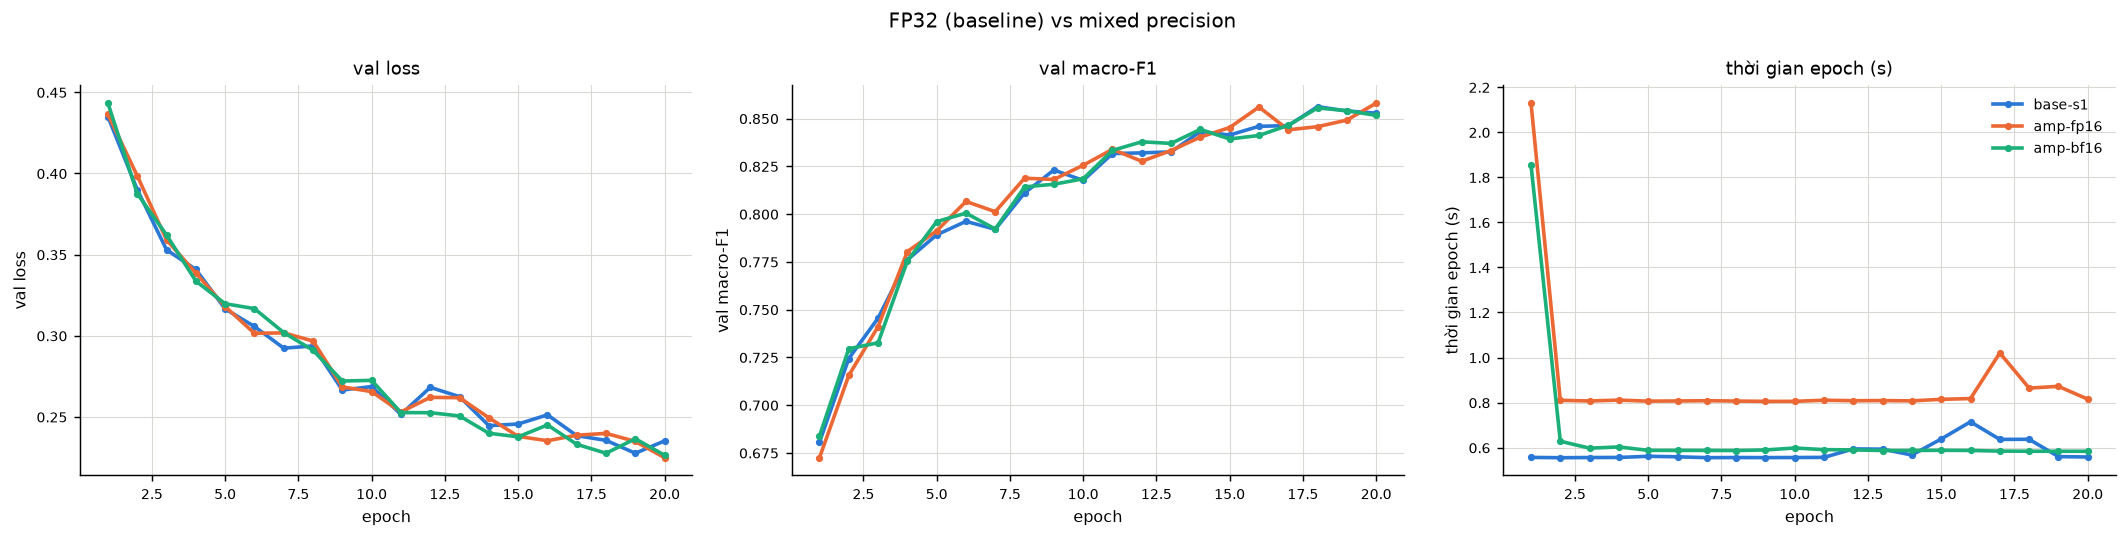

In [16]:
AMP_IDS, AMP_SKIPPED = [], {}
GPU_NAME = torch.cuda.get_device_name(0) if device == "cuda" else "Apple MPS"
if device == "cpu":
    AMP_SKIPPED = {p: "thiết bị là CPU, autocast FP16/BF16 trong lab này cần GPU" for p in ("fp16", "bf16")}
else:
    if device == "cuda":
        print("torch.cuda.is_bf16_supported():", torch.cuda.is_bf16_supported())
    for p in ("fp16", "bf16"):
        if p == "bf16" and device == "cuda" and not torch.cuda.is_bf16_supported():
            AMP_SKIPPED[p] = f"{torch.cuda.get_device_name(0)} không hỗ trợ BF16 (torch.cuda.is_bf16_supported() = False)"
            continue
        try:
            run(exp_id=f"amp-{p}", group="amp", precision=p,
                description=f"mixed precision {p.upper()}" + (" + GradScaler" if p == "fp16" else " (không GradScaler)"),
                note=f"GPU: {GPU_NAME}")
            AMP_IDS.append(f"amp-{p}")
        except Exception as e:   # ví dụ GPU/phiên bản không chạy được dtype này
            AMP_SKIPPED[p] = f"lỗi khi chạy: {type(e).__name__}: {e}"
for p, why in AMP_SKIPPED.items():
    print(f"KHÔNG chạy {p}: {why}")

if AMP_IDS:
    compare(["base-s1"] + AMP_IDS, extra=("precision",))
    display(pd.DataFrame([{"exp_id": i, "precision": RESULTS[i]["cfg"]["precision"], "s/epoch": RESULTS[i]["summary"]["time_per_epoch_s"],
                           "peak_mem_MB": RESULTS[i]["summary"]["peak_mem_MB"], "bước FP16 bị bỏ": RESULTS[i]["summary"]["amp_skipped_steps"]}
                          for i in ["base-s1"] + AMP_IDS]).set_index("exp_id").round(3))
    plot_compare([RESULTS[i] for i in ["base-s1"] + AMP_IDS], ["val_loss", "val_macro_f1", "epoch_time_s"],
                 f"{OUT_DIR}/figures/compare_amp.png", title="FP32 (baseline) vs mixed precision")
    show("compare_amp")

**Đối chiếu sau khi chạy** *(đo trên GPU Apple qua MPS, không phải CUDA)*

| exp_id | precision | val macro-F1 | Δ so với TB baseline | s/epoch | bộ nhớ (MB) |
|---|---|---|---|---|---|
| `base-s1` | fp32 | 0.8539 | 0 | 0.58 | 127.65 |
| `amp-fp16` | fp16 + GradScaler | 0.8580 | +0.0041 | 0.89 | 127.65 |
| `amp-bf16` | bf16 | 0.8516 | −0.0023 | 0.65 | 127.65 |

- **Độ chính xác:** cả hai trong nhiễu (|Δ| < 0.0234): hạ độ chính xác phép toán không đổi chất lượng.
- **Tốc độ: không nhanh hơn, mà chậm hơn**: FP16 chậm hơn 53% (0.89 so với 0.58 s/epoch), BF16 chậm hơn 13%. Khớp dự đoán. Mạng 48 nghìn tham số với lô 512 × 54 thì mỗi bước tốn chủ yếu cho chi phí gọi kernel, không phải phép nhân ma trận; autocast thêm bước ép kiểu, còn FP16 thêm `GradScaler` (scale, unscale, kiểm tra inf mỗi bước).
- **Bộ nhớ:** không đổi (127.65 MB), vì gần như toàn bộ là dữ liệu FP32 nằm sẵn trên GPU; kích hoạt của một lô chỉ vài trăm KB.
- **GradScaler có việc để làm:** FP16 có 3 bước gradient không hữu hạn bị bỏ qua, BF16 không có bước nào, đúng với việc FP16 có khoảng giá trị hẹp còn BF16 giữ số mũ 8 bit như FP32.
- **Hạn chế:** số đo thời gian/bộ nhớ là của MPS, nơi không có API đo đỉnh bộ nhớ (cột bộ nhớ là mức cấp phát lớn nhất ở cuối epoch). Trên GPU CUDA con số tuyệt đối sẽ khác; kết luận "mạng nhỏ thì không nhanh hơn" dự kiến vẫn đúng nhưng chưa được đo ở đây.

### Chủ đề 7 — Khởi tạo tham số (`init-…`)
`zeros` (W = 0), `normal` (N(0, 0,01²)), `xavier` (`xavier_normal_`, Var = 2/(n_vào + n_ra)), `default` (mặc định của `nn.Linear`), so với baseline `he` (Var = 2/n_vào). Bias = 0 trừ `default`.

**Dự đoán trước.**
- **zeros**: mạng **không học được gì ngoài bias lớp cuối**. Với W = 0 và b = 0, mọi kích hoạt ẩn bằng ReLU(0) = 0, nên gradient của W3 (= δ·h₂ᵀ) bằng 0, và gradient truyền ngược về lớp 1, 2 cũng bằng 0 (nhân với W3 = 0 và ReLU′(0) = 0). Chỉ b3 nhận gradient, nên mô hình hội tụ về việc dự đoán tần suất lớp: accuracy ≈ 0,4876, macro-F1 ≈ 0,094, loss bước 0 đúng bằng ln 7. Kể cả nếu có gradient thì mọi nơ-ron trong một lớp cũng nhận gradient giống hệt nhau (đối xứng không bị phá).
- **normal 0,01**: kích hoạt co dần qua từng lớp (std rất nhỏ), loss bước 0 ≈ ln 7; khởi đầu chậm (gradient nhỏ) nhưng mạng chỉ có 3 lớp nên vẫn thoát được và học gần bằng He, có thể chậm hơn vài epoch.
- **xavier / default**: gần He. Mạng 3 lớp không đủ sâu để hệ số 2 (He) so với 1 (Xavier) tạo khác biệt lớn; chênh lệch dự kiến trong 2σ.

,std sau ReLU 1,std sau ReLU 2,std logits,loss bước 0
init,,,,
zeros,0.00000,0.00000,0.00000,1.94591
normal,0.02027,0.00215,0.00027,1.94600
xavier,0.16282,0.12477,0.19156,2.02218
he,0.39012,0.36613,0.57728,2.26906
default,0.16028,0.06776,0.05851,1.98304


ln 7 = 1.9459


init-zeros               val loss 1.2052 @ep9  | acc 0.4876 | macro-F1 0.0936 | 0.58s/epoch


init-normal              val loss 0.2158 @ep20 | acc 0.9162 | macro-F1 0.8656 | 0.58s/epoch


init-xavier              val loss 0.2197 @ep20 | acc 0.9129 | macro-F1 0.8651 | 0.58s/epoch


init-default             val loss 0.2183 @ep19 | acc 0.9125 | macro-F1 0.8592 | 0.59s/epoch


,init,best_val_loss,best_epoch,val_acc,val_macro_f1,Δf1 vs base,vượt 2σ?,val−train loss,s/epoch,diverged
exp_id,,,,,,,,,,
base-s1,he,0.2276,19,0.9094,0.8539,-0.0000,Không,0.0269,0.5814,False
init-zeros,zeros,1.2052,9,0.4876,0.0936,-0.7603,Có,0.0000,0.5803,False
init-normal,normal,0.2158,20,0.9162,0.8656,0.0116,Không,0.0287,0.5847,False
init-xavier,xavier,0.2197,20,0.9129,0.8651,0.0111,Không,0.0264,0.5849,False
init-default,default,0.2183,19,0.9125,0.8592,0.0053,Không,0.0247,0.5913,False


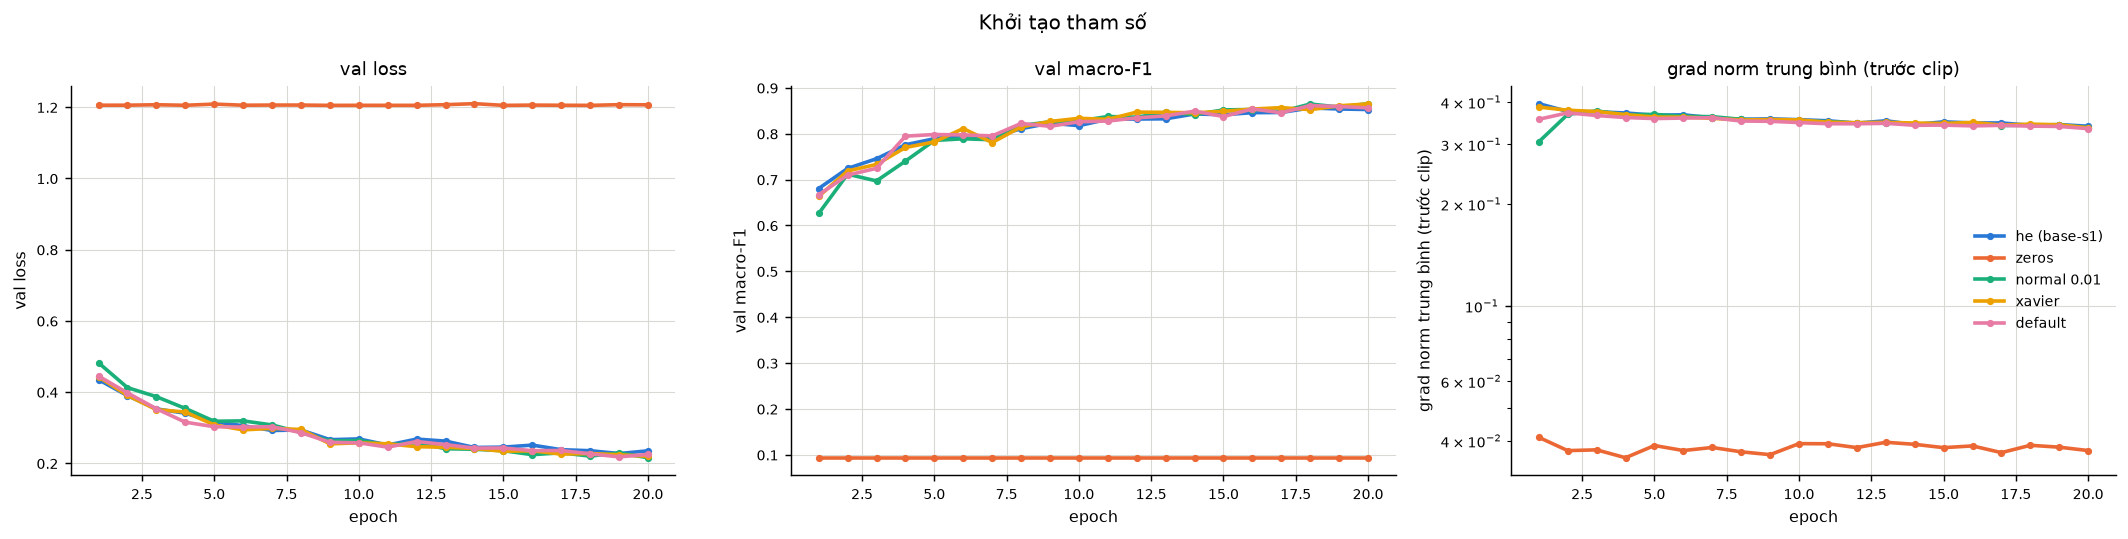

In [17]:
# Độ lệch chuẩn của kích hoạt theo lớp ở bước 0 (một lô val 4096 mẫu) và loss bước 0
xb_val = data["X_val"][:4096]
rows = []
for init in ("zeros", "normal", "xavier", "he", "default"):
    set_seed(1)
    m = MLP(hidden=(256, 128), init=init).to(device)
    a = activation_stats(m, xb_val)
    rows.append({"init": init, "std sau ReLU 1": a[0], "std sau ReLU 2": a[1], "std logits": a[2],
                 "loss bước 0": evaluate(m, data["X_val"], data["y_val"], "ce")["loss"]})
display(pd.DataFrame(rows).set_index("init").round(5))
print(f"ln 7 = {math.log(7):.4f}")

# std kích hoạt ở bước 0 được ghi vào cột notes của bảng (dòng he là base-s1)
ACT_NOTE = {r["init"]: "bước 0: std sau ReLU 1 / ReLU 2 / logits = %.4f / %.4f / %.4f" % (r["std sau ReLU 1"], r["std sau ReLU 2"], r["std logits"]) for r in rows}
NOTES["base-s1"] += "; " + ACT_NOTE["he"]
INIT_IDS = []
for init in ("zeros", "normal", "xavier", "default"):
    INIT_IDS.append(run(exp_id=f"init-{init}", group="init", init=init, description=f"khởi tạo {init} thay cho he", note=ACT_NOTE[init])["cfg"]["exp_id"])
compare(["base-s1"] + INIT_IDS, extra=("init",))
plot_compare([RESULTS[i] for i in ["base-s1"] + INIT_IDS], ["val_loss", "val_macro_f1", "grad_norm"], f"{OUT_DIR}/figures/compare_init.png",
             title="Khởi tạo tham số", labels=["he (base-s1)", "zeros", "normal 0.01", "xavier", "default"])
show("compare_init")

**Đối chiếu sau khi chạy.**

| init | std sau ReLU 1 | std sau ReLU 2 | std logits | loss bước 0 | val macro-F1 | Δ so với TB baseline |
|---|---|---|---|---|---|---|
| zeros | 0 | 0 | 0 | 1.9459 | 0.0936 | −0.7603 |
| normal 0.01 | 0.0203 | 0.0022 | 0.0003 | 1.9460 | 0.8656 | +0.0116 |
| xavier | 0.163 | 0.125 | 0.192 | 2.0222 | 0.8651 | +0.0111 |
| default | 0.160 | 0.068 | 0.059 | 1.9830 | 0.8592 | +0.0053 |
| he (`base-s1`) | 0.390 | 0.366 | 0.577 | 2.2691 | 0.8539 | 0 |

- **zeros: khớp dự đoán hoàn toàn.** Accuracy 0.4876 và macro-F1 0.0936, đúng bằng "đoán lớp đa số"; loss bước 0 đúng bằng ln 7; val loss dừng ở 1.205 (entropy của phân bố lớp). Chuẩn gradient trung bình chỉ 0.038 và toàn bộ đến từ bias lớp cuối: kích hoạt ẩn bằng 0 nên gradient của mọi trọng số bằng 0.
- **Std kích hoạt:** `he` giữ std gần như không đổi qua hai lớp ẩn (0.39 → 0.37), `xavier` giảm nhẹ (0.16 → 0.12), `normal 0.01` co ~10 lần mỗi lớp (0.020 → 0.002 → 0.0003), đúng xu hướng biểu đồ "30 lớp ReLU" của slide. Loss bước 0 càng gần ln 7 khi logit càng nhỏ.
- **normal / xavier / default so với he:** cả ba đều trong nhiễu (|Δ| ≤ 0.0116 < 0.0234). Khác một phần dự đoán: `normal 0.01` không chậm hơn đo được, dù kích hoạt co 10 lần mỗi lớp. Mạng chỉ có 3 lớp tuyến tính nên tín hiệu chưa kịp triệt tiêu, và vài chục bước SGD với lr 0.3 đã đưa thang trọng số về mức hợp lý. Kết luận: với mạng nông này, miễn là phá được đối xứng thì cách khởi tạo không tạo khác biệt đo được; He so với Xavier chỉ quan trọng khi mạng sâu, nơi hệ số phương sai nhân dồn qua từng lớp.

### Thêm — Lịch tốc độ học cosine (`sched-cosine`, nhóm `other`)
**Dự đoán trước.** Giảm lr theo cosine từ lr baseline về 0 trong 20 epoch sẽ cho val loss cuối thấp hơn baseline: lr lớn ở đầu để đi nhanh, lr nhỏ ở cuối để giảm nhiễu của SGD quanh điểm tối ưu (đường val loss mượt dần). Cải thiện dự kiến vượt 2σ.

sched-cosine             val loss 0.1652 @ep20 | acc 0.9354 | macro-F1 0.8916 | 0.63s/epoch


,scheduler,best_val_loss,best_epoch,val_acc,val_macro_f1,Δf1 vs base,vượt 2σ?,val−train loss,s/epoch,diverged
exp_id,,,,,,,,,,
base-s1,NaN,0.2276,19,0.9094,0.8539,-0.0000,Không,0.0269,0.5814,False
sched-cosine,cosine,0.1652,20,0.9354,0.8916,0.0376,Có,0.0297,0.6253,False


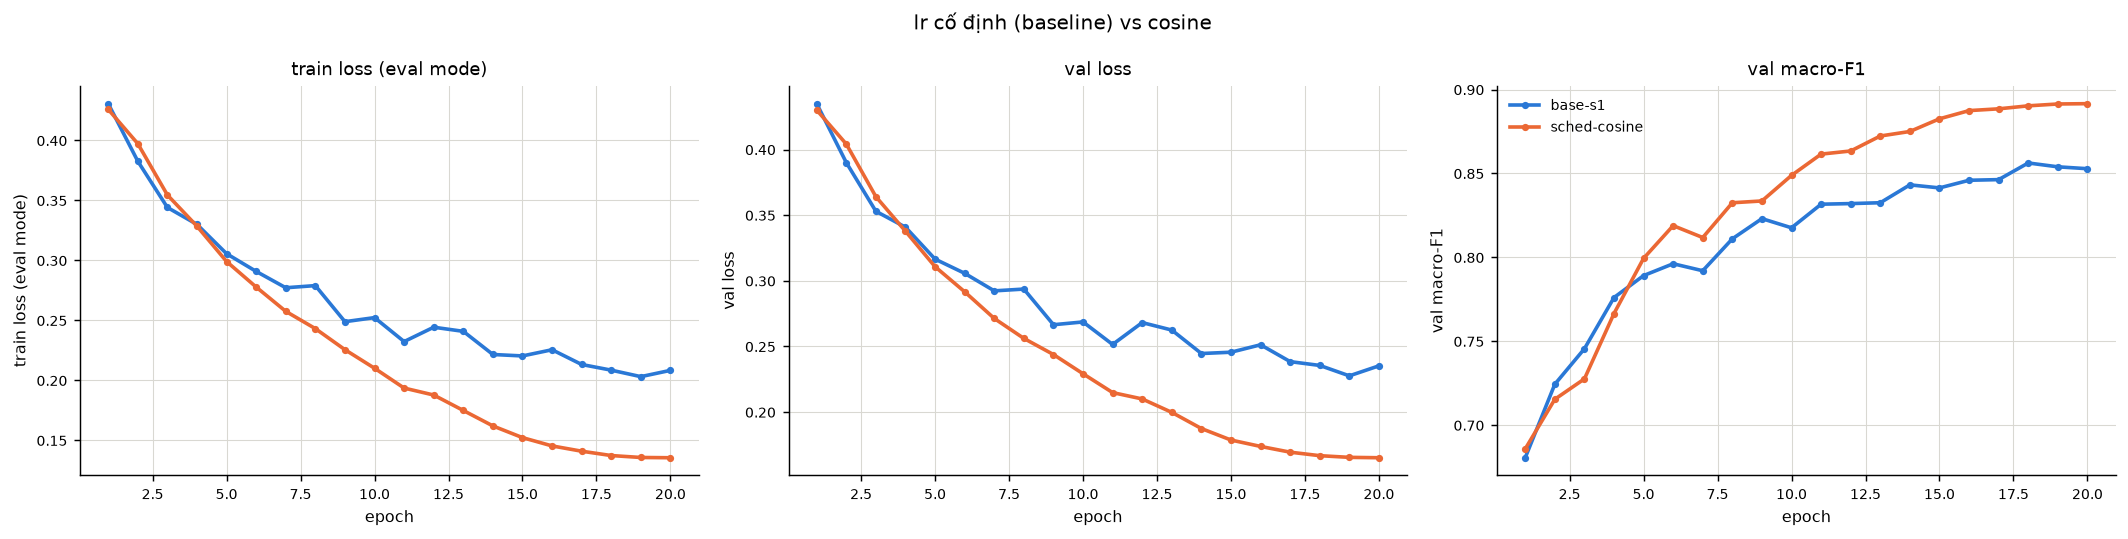

In [18]:
run(exp_id="sched-cosine", group="other", scheduler="cosine", description="lr giảm theo cosine về 0 trong 20 epoch (CosineAnnealingLR theo bước)")
compare(["base-s1", "sched-cosine"], extra=("scheduler",))
plot_compare([RESULTS["base-s1"], RESULTS["sched-cosine"]], ["train_loss", "val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_scheduler.png", title="lr cố định (baseline) vs cosine")
show("compare_scheduler")

**Đối chiếu sau khi chạy.** Khớp dự đoán. `sched-cosine` đạt val macro-F1 0.8916 (Δ +0.0376, vượt 2σ = 0.0234), val loss 0.1652 so với 0.2276 của `base-s1`, accuracy 0.9354 so với 0.9094. Đây là cải thiện đơn lẻ lớn nhất trong mọi thí nghiệm một yếu tố, lớn hơn cả đổi sang Adam hay mạng rộng. Nó khớp với quan sát ở baseline: lr = 0.3 cố định làm val loss răng cưa ở các epoch cuối; giảm dần lr về 0 loại nhiễu đó và cho mô hình "lắng" vào điểm tối ưu. Khoảng cách val − train là 0.030, vẫn chưa quá khớp.

### Kết hợp — cấu hình cuối cùng (chọn **chỉ bằng val**)
Quy tắc chọn được viết thành code, cố định trước khi nhìn bất kỳ điểm eval nào:
- **Bộ tối ưu + lr:** lần chạy có val macro-F1 cao nhất trong nhóm optimizer và lưới lr của SGD+momentum.
- **Kiến trúc:** tốt nhất theo val trong `M-base` / `M-wide` / `M-deep`.
- **Số epoch, lịch cosine, dropout:** chỉ thêm nếu thí nghiệm tương ứng vượt baseline hơn 2σ trên val.
- Batch 512, He, CE, FP32, không clip, giữ như baseline.

Các yếu tố được chọn riêng lẻ rồi ghép lại, nên có thể tương tác với nhau; vì thế cấu hình ghép được chạy 3 seed và kiểm tra lại trên val trước khi sang Part 4.

chọn từ: {'optimizer+lr': 'opt-adam-lr0.003', 'kiến trúc': 'hp-wide', 'epochs': 'baseline', 'scheduler': 'sched-cosine', 'dropout': 'không'}
khác baseline ở: {'optimizer': 'adam', 'lr': 0.003, 'hidden': (512, 256), 'scheduler': 'cosine'}


final-s1                 val loss 0.1464 @ep20 | acc 0.9430 | macro-F1 0.9133 | 1.02s/epoch


final-s2                 val loss 0.1520 @ep20 | acc 0.9415 | macro-F1 0.9085 | 1.02s/epoch


final-s3                 val loss 0.1501 @ep20 | acc 0.9418 | macro-F1 0.9092 | 1.02s/epoch

final:    val macro-F1 = 0.9103 ± 0.0026 (3 seed)
baseline: val macro-F1 = 0.8540 ± 0.0117 -> chênh +0.0564, ngưỡng 2σ = 0.0234


,optimizer,lr,hidden,epochs,scheduler,dropout,best_val_loss,best_epoch,val_acc,val_macro_f1,Δf1 vs base,vượt 2σ?,val−train loss,s/epoch,diverged
exp_id,,,,,,,,,,,,,,,
base-s1,sgd_momentum,0.300,"(256, 128)",20,NaN,0.0,0.2276,19,0.9094,0.8539,-0.0000,Không,0.0269,0.5814,False
base-s2,sgd_momentum,0.300,"(256, 128)",20,NaN,0.0,0.2133,19,0.9160,0.8657,0.0117,Không,0.0281,0.5776,False
base-s3,sgd_momentum,0.300,"(256, 128)",20,NaN,0.0,0.2199,20,0.9144,0.8423,-0.0117,Không,0.0222,0.5689,False
final-s1,adam,0.003,"(512, 256)",20,cosine,0.0,0.1464,20,0.9430,0.9133,0.0594,Có,0.0360,1.0186,False
final-s2,adam,0.003,"(512, 256)",20,cosine,0.0,0.1520,20,0.9415,0.9085,0.0545,Có,0.0356,1.0247,False
final-s3,adam,0.003,"(512, 256)",20,cosine,0.0,0.1501,20,0.9418,0.9092,0.0552,Có,0.0358,1.0205,False


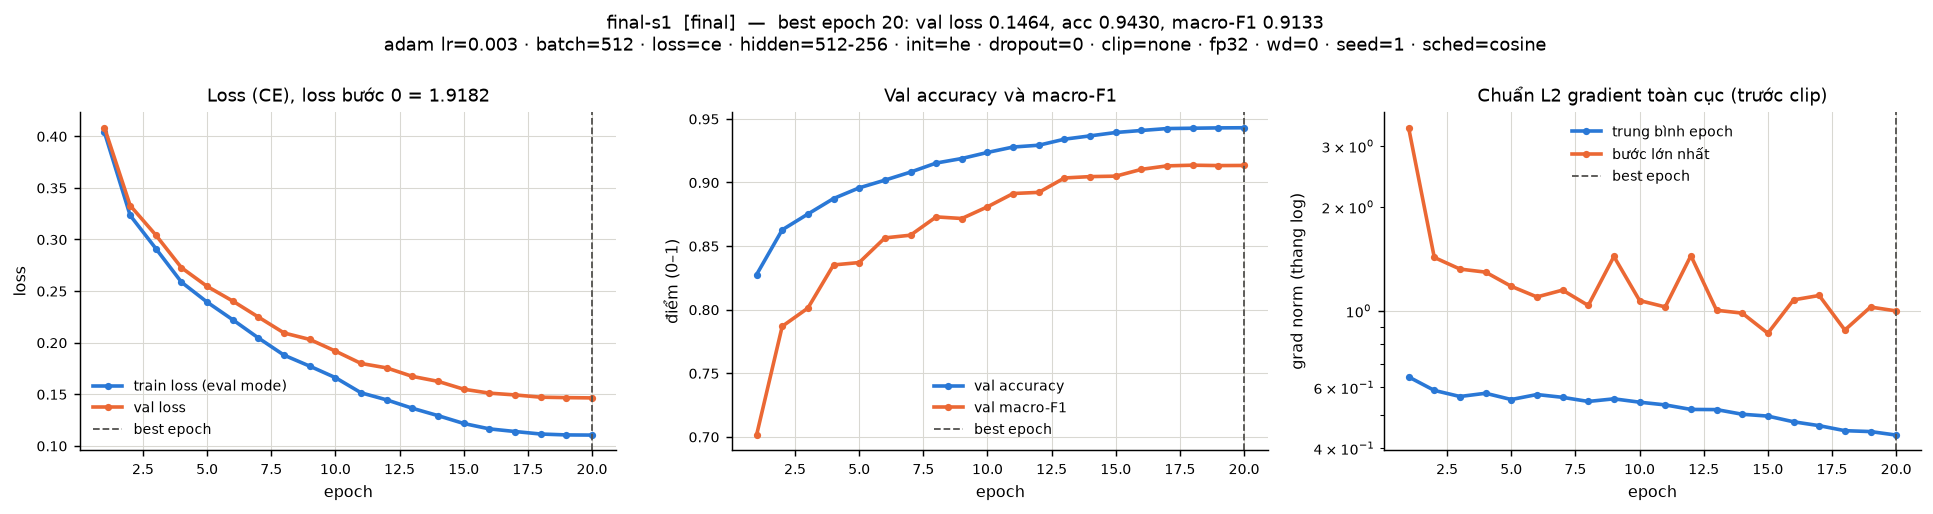

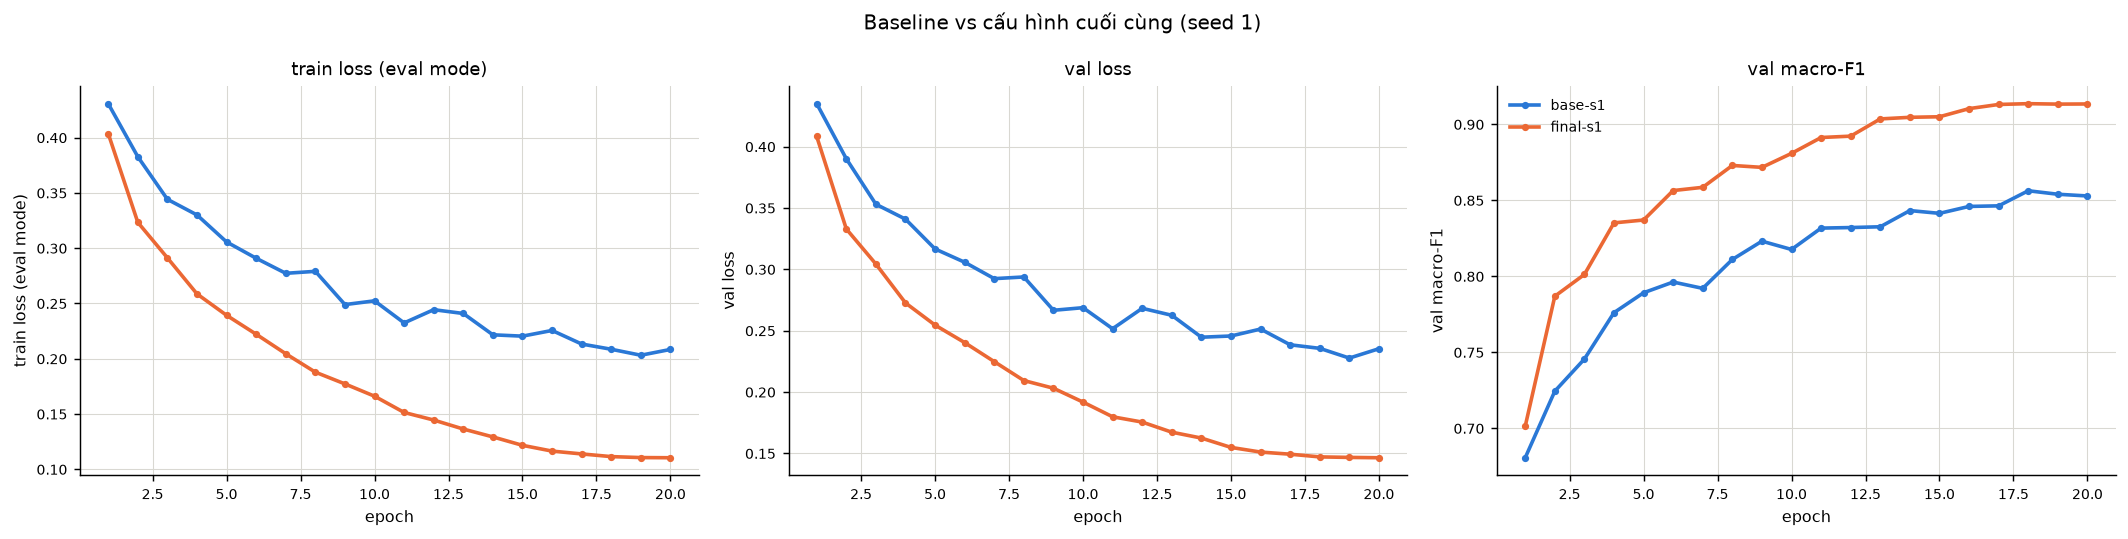

In [19]:
def beats_base(exp_id):
    return f1_of(exp_id) - BASE_F1 > NOISE_F1

opt_candidates = [i for ids in OPT_RUNS.values() for i in ids]
best_opt_id  = max(opt_candidates, key=f1_of)
best_arch_id = max(["base-s1", "hp-wide", "hp-deep"], key=f1_of)
best_drop_id = max(DROP_IDS, key=f1_of)

oc = RESULTS[best_opt_id]["cfg"]
FINAL_CFG = {**BASE_CFG, "group": "final",
             "optimizer": oc["optimizer"], "lr": oc["lr"], "weight_decay": oc["weight_decay"],
             "hidden": RESULTS[best_arch_id]["cfg"]["hidden"],
             "epochs": 40 if beats_base("hp-ep40") else EPOCHS,
             "scheduler": "cosine" if beats_base("sched-cosine") else None,
             "dropout": RESULTS[best_drop_id]["cfg"]["dropout"] if beats_base(best_drop_id) else 0.0}
print("chọn từ:", {"optimizer+lr": best_opt_id, "kiến trúc": best_arch_id, "epochs": "hp-ep40" if FINAL_CFG["epochs"] == 40 else "baseline",
                   "scheduler": "sched-cosine" if FINAL_CFG["scheduler"] else "không", "dropout": best_drop_id if FINAL_CFG["dropout"] else "không"})
changed = {k: v for k, v in FINAL_CFG.items() if BASE_CFG.get(k) != v and k != "group"}
print("khác baseline ở:", changed)

FINAL_IDS = []
for seed in (1, 2, 3):
    r = register(run_experiment({**FINAL_CFG, "seed": seed, "exp_id": f"final-s{seed}",
                                 "description": "Cấu hình cuối: " + ", ".join(f"{k}={v}" for k, v in changed.items())}, data),
                 "kết hợp nhiều yếu tố, mỗi yếu tố chọn bằng val")
    FINAL_IDS.append(r["cfg"]["exp_id"])

final_f1 = np.array([f1_of(i) for i in FINAL_IDS])
print(f"\nfinal:    val macro-F1 = {final_f1.mean():.4f} ± {final_f1.std(ddof=1):.4f} (3 seed)")
print(f"baseline: val macro-F1 = {BASE_F1:.4f} ± {NOISE_F1 / 2:.4f} -> chênh {final_f1.mean() - BASE_F1:+.4f}, ngưỡng 2σ = {NOISE_F1:.4f}")
compare(BASE_IDS + FINAL_IDS, extra=("optimizer", "lr", "hidden", "epochs", "scheduler", "dropout"))
plot_compare([RESULTS[i] for i in ("base-s1", "final-s1")], ["train_loss", "val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_final.png", title="Baseline vs cấu hình cuối cùng (seed 1)")
show("final-s1"); show("compare_final")

**Nhận xét cấu hình cuối cùng.** Quy tắc chọn ra: **Adam lr 0.003 + `M-wide` (512-256) + lịch cosine**, 20 epoch, không dropout (dropout và 40 epoch không vượt 2σ nên không được thêm).
- Val macro-F1 = **0.9103 ± 0.0026** qua 3 seed (0.9133 / 0.9085 / 0.9092), so với baseline 0.8540 ± 0.0117: chênh **+0.0564**, gấp hơn hai lần ngưỡng 2σ = 0.0234. Val accuracy 0.942 so với 0.913.
- Cải thiện riêng lẻ: Adam +0.0249, `M-wide` +0.0236, cosine +0.0376; tổng 0.086 nhưng ghép lại chỉ được 0.056. Các yếu tố **chồng lấn**: cả ba cùng giải quyết việc baseline "chưa khớp hết / bước cập nhật còn nhiễu".
- Độ lệch chuẩn giữa các seed giảm từ 0.0117 xuống 0.0026: lr về 0 ở cuối làm kết quả ít phụ thuộc vào epoch dừng.
- Khoảng cách val − train tăng lên 0.036 (train 0.110, val 0.146): mạng rộng bắt đầu khớp train tốt hơn val, nhưng val loss vẫn giảm đến epoch cuối.
- Mô hình nộp là `final-s1`.

## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
Cấu hình đã chốt ở trên bằng val. Bây giờ mới dùng tập eval, đúng hai lần: `base-s1` (để có mốc so sánh) và `final-s1` (mô hình nộp). Điểm do `scripts/evaluate.py` tính; không chỉnh lại cấu hình sau bước này.

In [20]:
# Baseline: dự đoán ghi ra thư mục tạm (không nộp), chỉ giữ lại điểm
tmp = tempfile.mkdtemp()
print("===== base-s1 trên eval =====")
EVAL_BASE = final_eval(RESULTS["base-s1"]["cfg"], RESULTS["base-s1"], data, f"{tmp}/predictions_base.csv",
                       repo_root=REPO_ROOT, out_json=f"{tmp}/eval_base.json")

# Cấu hình cuối cùng (seed 1): file nộp predictions_eval.csv + eval_result.json
print("===== final-s1 trên eval =====")
EVAL_FINAL = final_eval(RESULTS["final-s1"]["cfg"], RESULTS["final-s1"], data, f"{OUT_DIR}/predictions_eval.csv",
                        repo_root=REPO_ROOT, out_json=f"{OUT_DIR}/eval_result.json")

display(pd.DataFrame([
    {"cấu hình": "baseline (base-s1)", "val macro-F1": f1_of("base-s1"), "eval macro-F1": EVAL_BASE["macro_f1"], "eval accuracy": EVAL_BASE["accuracy"]},
    {"cấu hình": "cuối cùng (final-s1)", "val macro-F1": f1_of("final-s1"), "eval macro-F1": EVAL_FINAL["macro_f1"], "eval accuracy": EVAL_FINAL["accuracy"]},
]).set_index("cấu hình").round(4))
print(f"cải thiện trên eval: {EVAL_FINAL['macro_f1'] - EVAL_BASE['macro_f1']:+.4f} macro-F1 (ngưỡng nhiễu 2σ đo trên val: {NOISE_F1:.4f})")

===== base-s1 trên eval =====


n_eval = 116203
accuracy = 0.9085
macro_f1 = 0.8585   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.8993  0.9156  0.9074
  1    56661     0.9247  0.9197  0.9222
  2     7151     0.9127  0.8934  0.9030
  3      549     0.7620  0.8689  0.8119
  4     1899     0.7585  0.7162  0.7367
  5     3473     0.8109  0.8321  0.8214
  6     4102     0.9525  0.8657  0.9070

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  38791   3384     6    0    27    12   148
1   3808  52113   144    1   359   207    29
2      0    183  6389  118    39   422     0
3      0      0    54  477     0    18     0
4     40    465    19    0  1360    15     0
5      6    151   388   30     8  2890     0
6    490     61     0    0     0     0  3551

đã ghi /var/folders/jw/lvwd502d489g9xqmscn73fmh0000gn/T/tmpkuguaq1c/eval_base.json

===== final-s1 trên eval =====


n_eval = 116203
accuracy = 0.9421
macro_f1 = 0.9147   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9438  0.9331  0.9384
  1    56661     0.9458  0.9559  0.9508
  2     7151     0.9410  0.9435  0.9423
  3      549     0.8757  0.8597  0.8676
  4     1899     0.8864  0.8462  0.8658
  5     3473     0.8901  0.8837  0.8869
  6     4102     0.9537  0.9483  0.9510

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  39534   2632     2    0    23     7   170
1   2131  54160    89    0   162   100    19
2      2    111  6747   43    16   232     0
3      0      0    50  472     0    27     0
4     34    233    12    0  1607    13     0
5      8     97   270   24     5  3069     0
6    180     32     0    0     0     0  3890

đã ghi /Users/doananhquan/Documents/AI thực chiến/Day 16/K4-Track4-Day1-Neuralnetwork/submission_2A202602803/eval_result.json



,val macro-F1,eval macro-F1,eval accuracy
cấu hình,,,
baseline (base-s1),0.8539,0.8585,0.9085
cuối cùng (final-s1),0.9133,0.9147,0.9421


cải thiện trên eval: +0.0562 macro-F1 (ngưỡng nhiễu 2σ đo trên val: 0.0234)


,tên,support,precision,recall,f1,F1 baseline
cls,,,,,,
0,Spruce/Fir,42368,0.9438,0.9331,0.9384,0.9074
1,Lodgepole Pine,56661,0.9458,0.9559,0.9508,0.9222
2,Ponderosa Pine,7151,0.9410,0.9435,0.9423,0.9030
3,Cottonwood/Willow,549,0.8757,0.8597,0.8676,0.8119
4,Aspen,1899,0.8864,0.8462,0.8658,0.7367
5,Douglas-fir,3473,0.8901,0.8837,0.8869,0.8214
6,Krummholz,4102,0.9537,0.9483,0.9510,0.9070


,đoán 0,đoán 1,đoán 2,đoán 3,đoán 4,đoán 5,đoán 6
thật 0,39534,2632,2,0,23,7,170
thật 1,2131,54160,89,0,162,100,19
thật 2,2,111,6747,43,16,232,0
thật 3,0,0,50,472,0,27,0
thật 4,34,233,12,0,1607,13,0
thật 5,8,97,270,24,5,3069,0
thật 6,180,32,0,0,0,0,3890


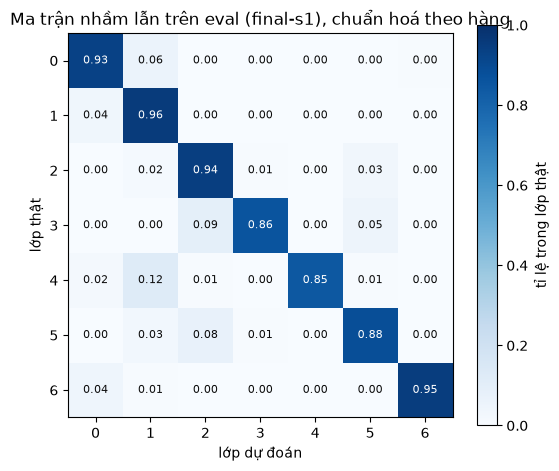

lớp khó nhất: 4 (Aspen), F1 = 0.8658, support = 1899
  lớp 4 (Aspen): bỏ sót nhiều nhất sang lớp 1 (233 mẫu = 12.3% của lớp); bị nhận nhầm nhiều nhất từ lớp 1 (162 mẫu)
  lớp 3 (Cottonwood/Willow): bỏ sót nhiều nhất sang lớp 2 (50 mẫu = 9.1% của lớp); bị nhận nhầm nhiều nhất từ lớp 2 (43 mẫu)
  lớp 5 (Douglas-fir): bỏ sót nhiều nhất sang lớp 2 (270 mẫu = 7.8% của lớp); bị nhận nhầm nhiều nhất từ lớp 2 (232 mẫu)


In [21]:
# Phân tích lỗi trên eval từ eval_result.json: precision/recall/F1 từng lớp và ma trận nhầm lẫn
CLASS_NAMES = ["Spruce/Fir", "Lodgepole Pine", "Ponderosa Pine", "Cottonwood/Willow", "Aspen", "Douglas-fir", "Krummholz"]
with open(f"{OUT_DIR}/eval_result.json") as f:
    ev = json.load(f)
per_class = pd.DataFrame(ev["per_class"]).set_index("cls")
per_class.insert(0, "tên", CLASS_NAMES)
per_class["F1 baseline"] = [c["f1"] for c in EVAL_BASE["per_class"]]
display(per_class.round(4))

cm = np.array(ev["confusion_matrix"])
display(pd.DataFrame(cm, index=[f"thật {c}" for c in range(7)], columns=[f"đoán {c}" for c in range(7)]))

cm_norm = cm / cm.sum(axis=1, keepdims=True)   # chuẩn hoá theo hàng: mỗi ô = tỉ lệ mẫu của lớp thật
fig, ax = plt.subplots(figsize=(6.2, 5.2))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
for i in range(7):
    for j in range(7):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", fontsize=8, color="white" if cm_norm[i, j] > 0.5 else "#0b0b0b")
ax.set_xticks(range(7)); ax.set_yticks(range(7)); ax.set_xlabel("lớp dự đoán"); ax.set_ylabel("lớp thật")
ax.set_title("Ma trận nhầm lẫn trên eval (final-s1), chuẩn hoá theo hàng")
fig.colorbar(im, ax=ax, label="tỉ lệ trong lớp thật"); plt.show()

worst = int(per_class["f1"].idxmin())
print(f"lớp khó nhất: {worst} ({CLASS_NAMES[worst]}), F1 = {per_class.loc[worst, 'f1']:.4f}, support = {per_class.loc[worst, 'support']}")
for c in np.argsort(per_class["f1"].to_numpy())[:3]:
    row, col = cm[c].copy(), cm[:, c].copy()
    row[c] = 0; col[c] = 0
    print(f"  lớp {c} ({CLASS_NAMES[c]}): bỏ sót nhiều nhất sang lớp {row.argmax()} ({row.max()} mẫu = {row.max() / cm[c].sum():.1%} của lớp); "
          f"bị nhận nhầm nhiều nhất từ lớp {col.argmax()} ({col.max()} mẫu)")

**Phân tích lỗi (trên eval, `final-s1`).**
- **Lớp khó nhất: lớp 4 (Aspen)**, F1 = 0.8658 (precision 0.8864, recall 0.8462, 1 899 mẫu). Sát nút là lớp 3 (Cottonwood/Willow, F1 0.8676, chỉ 549 mẫu) và lớp 5 (Douglas-fir, F1 0.8869). Bốn lớp còn lại (0, 1, 2, 6) đều trên 0.938.
- **Nhầm với lớp nào:** Aspen bị bỏ sót chủ yếu sang lớp 1 (Lodgepole Pine): 233 mẫu = 12.3% của lớp, và 162 mẫu lớp 1 bị đoán thành Aspen. Lớp 3 và lớp 5 nhầm qua lại với lớp 2 (Ponderosa Pine): 50 mẫu lớp 3 → 2, 270 mẫu lớp 5 → 2 và 232 mẫu lớp 2 → 5. Cặp nhầm lớn nhất về số lượng tuyệt đối vẫn là 0 ↔ 1 (2 632 và 2 131 mẫu), nhưng chỉ chiếm 6.2% và 3.8% của hai lớp đó.
- **Vì sao:** (1) mất cân bằng: lớp 1 nhiều gấp 30 lần lớp 4, nên CE không trọng số ưu tiên lớp 1 ở vùng chồng lấn, khiến recall của Aspen (0.846) thấp hơn precision (0.886); (2) tương đồng đặc trưng: ma trận nhầm lẫn chia thành hai cụm gần như tách rời, {0, 1, 4, 6} và {2, 3, 5} (ví dụ không có mẫu lớp 3 nào bị đoán thành 0, 1, 4, 6), phù hợp với việc hai nhóm loài sống ở hai dải độ cao khác nhau; trong mỗi cụm các lớp dùng chung loại đất và vùng hoang dã nên khó tách. Giải thích theo độ cao là suy luận từ cấu trúc nhầm lẫn, tôi chưa đo trực tiếp phân bố `Elevation` theo lớp.
- **So với baseline:** F1 của lớp 4 tăng nhiều nhất, 0.7367 → 0.8658; lớp 3: 0.8119 → 0.8676; lớp 5: 0.8214 → 0.8869. Cải thiện của cấu hình cuối đến chủ yếu từ các lớp hiếm.
- **Val và eval:** val macro-F1 0.9133 so với eval 0.9147 (`final-s1`), và 0.8539 so với 0.8585 (`base-s1`): chênh ≤ 0.005, val là ước lượng đáng tin của eval.
- **Cải thiện sẽ thử** (chọn bằng val): CE có trọng số theo lớp hoặc lấy mẫu cân bằng để nâng recall lớp 3, 4, 5.

In [22]:
# Bảng experiments.xlsx: mỗi lần chạy một dòng, thứ tự theo nhóm; điểm eval chỉ điền cho base-s1 và final-s1
GROUP_ORDER = ["baseline", "loss", "optimizer", "hparam", "dropout", "clipping", "amp", "init", "final", "other"]
loaded = {r["cfg"]["exp_id"]: r for r in load_results(f"{OUT_DIR}/results")}
ordered = sorted(RESULTS, key=lambda i: (GROUP_ORDER.index(RESULTS[i]["cfg"]["group"]), list(RESULTS).index(i)))
assert all(i in loaded for i in ordered)
EVAL_SCORES = {"base-s1": EVAL_BASE, "final-s1": EVAL_FINAL}
rows = [to_row(loaded[i], eval_scores=EVAL_SCORES.get(i), notes=NOTES.get(i, "")) for i in ordered]

def group_note(group):
    # Nhận xét ngắn cho sheet Summary, sinh từ số đo trên val
    ids = [i for i in ordered if RESULTS[i]["cfg"]["group"] == group and RESULTS[i]["summary"]["val_macro_f1"] is not None]
    if not ids:
        return ""
    best = max(ids, key=f1_of)
    d = f1_of(best) - BASE_F1
    n_div = sum(RESULTS[i]["summary"]["diverged"] for i in ordered if RESULTS[i]["cfg"]["group"] == group)
    return (f"Tốt nhất: {best} (val macro-F1 {f1_of(best):.4f}, Δ {d:+.4f} so với TB baseline; "
            f"{'vượt' if abs(d) > NOISE_F1 else 'KHÔNG vượt'} ngưỡng 2σ = {NOISE_F1:.4f})" + (f"; {n_div} lần phân kỳ" if n_div else ""))

summary_notes = {g: group_note(g) for g in GROUP_ORDER}
summary_notes["baseline"] = f"3 seed: val macro-F1 {BASE_F1:.4f} ± {NOISE_F1 / 2:.4f}; lr={BASE_LR:g} chọn bằng val"
if AMP_SKIPPED:
    summary_notes["amp"] = (summary_notes["amp"] + "; " if summary_notes["amp"] else "") + "không chạy: " + "; ".join(f"{p} ({w})" for p, w in AMP_SKIPPED.items())

# Mẫu bảng nằm ở templates/ của repo; nếu chỉ có thư mục nộp + data/ + scripts/ thì dùng chính experiments.xlsx đã nộp làm mẫu
TEMPLATE = f"{REPO_ROOT}/templates/experiment_table_template.xlsx"
if not os.path.exists(TEMPLATE):
    TEMPLATE = f"{OUT_DIR}/experiments.xlsx"
write_xlsx(rows, TEMPLATE, f"{OUT_DIR}/experiments.xlsx",
           seed_ids=BASE_IDS, summary_notes=summary_notes)
table = pd.DataFrame(rows)
pd.set_option("display.max_rows", 100, "display.max_columns", 40, "display.width", 250)
display(table.drop(columns=["description", "notes", "figure_file"]).round(4))
print(f"đã ghi {OUT_DIR}/experiments.xlsx với {len(rows)} dòng; chủ đề đã thử: {sorted(set(table['group']) - {'baseline', 'final', 'other'})}")

,exp_id,group,loss,optimizer,lr,weight_decay,batch,epochs,hidden,dropout,clip_norm,precision,init,seed,diverged,eval_acc,eval_macro_f1,step0_loss,best_val_loss,best_epoch,final_train_loss,final_val_loss,val_acc,val_macro_f1,time_per_epoch_s,peak_mem_MB
0,base-s1,baseline,CE,SGD+momentum,0.3000,0.0000,512,20,256-128,0.0,none,fp32,he,1,N,0.9085,0.8585,2.2691,0.2276,19,0.2083,0.2352,0.9094,0.8539,0.5814,127.6504
1,base-s2,baseline,CE,SGD+momentum,0.3000,0.0000,512,20,256-128,0.0,none,fp32,he,2,N,NaN,NaN,1.9782,0.2133,19,0.1872,0.2153,0.9160,0.8657,0.5776,127.6504
2,base-s3,baseline,CE,SGD+momentum,0.3000,0.0000,512,20,256-128,0.0,none,fp32,he,3,N,NaN,NaN,1.9005,0.2199,20,0.1977,0.2199,0.9144,0.8423,0.5689,127.6504
3,loss-mse,loss,MSE,SGD+momentum,0.3000,0.0000,512,20,256-128,0.0,none,fp32,he,1,N,NaN,NaN,0.6359,0.0271,20,0.0261,0.0271,0.8825,0.7839,0.5064,127.6538
4,opt-sgd-lr0.03,optimizer,CE,SGD,0.0300,0.0000,512,20,256-128,0.0,none,fp32,he,1,N,NaN,NaN,2.2691,0.4308,18,0.4270,0.4334,0.8203,0.6646,0.5724,127.4675
5,opt-sgd-lr0.1,optimizer,CE,SGD,0.1000,0.0000,512,20,256-128,0.0,none,fp32,he,1,N,NaN,NaN,2.2691,0.3485,18,0.4193,0.4289,0.8537,0.7421,0.5578,127.4675
6,opt-sgd-lr0.3,optimizer,CE,SGD,0.3000,0.0000,512,20,256-128,0.0,none,fp32,he,1,N,NaN,NaN,2.2691,0.2950,16,0.4034,0.4193,0.8773,0.7946,0.5546,127.4675
7,opt-adam-lr0.0003,optimizer,CE,Adam,0.0003,0.0000,512,20,256-128,0.0,none,fp32,he,1,N,NaN,NaN,2.2691,0.3084,20,0.2966,0.3084,0.8760,0.7941,0.7742,127.8333
8,opt-adam-lr0.001,optimizer,CE,Adam,0.0010,0.0000,512,20,256-128,0.0,none,fp32,he,1,N,NaN,NaN,2.2691,0.2430,18,0.2261,0.2468,0.9038,0.8433,0.8153,127.8333
9,opt-adam-lr0.003,optimizer,CE,Adam,0.0030,0.0000,512,20,256-128,0.0,none,fp32,he,1,N,NaN,NaN,2.2691,0.2093,20,0.1813,0.2093,0.9161,0.8789,0.7877,127.8333


đã ghi ../experiments.xlsx với 40 dòng; chủ đề đã thử: ['amp', 'clipping', 'dropout', 'hparam', 'init', 'loss', 'optimizer']


In [23]:
# Tự kiểm tra trước khi nộp và đóng gói
fig_dir = f"{OUT_DIR}/figures"
run_figs = {f[:-4] for f in os.listdir(fig_dir) if f.endswith(".png") and not f.startswith("compare_")}
assert run_figs == set(ordered), f"ảnh và dòng bảng lệch nhau: {run_figs ^ set(ordered)}"
print(f"{len(run_figs)} ảnh figures/<exp_id>.png = {len(rows)} dòng bảng  ✓")
print("ảnh so sánh:", sorted(f for f in os.listdir(fig_dir) if f.startswith("compare_")))

for f in os.listdir("."):
    if f.endswith(".py"):
        assert "NotImplementedError" not in open(f, encoding="utf-8").read(), f
print("không còn NotImplementedError trong code/  ✓")

pred = pd.read_csv(f"{OUT_DIR}/predictions_eval.csv")
assert list(pred.columns) == ["row_id", "pred"] and len(pred) == 116_203 and pred["row_id"].is_unique and pred["pred"].between(0, 6).all()
print("predictions_eval.csv hợp lệ; eval_result.json: macro_f1 = %.4f, accuracy = %.4f  ✓" % (EVAL_FINAL["macro_f1"], EVAL_FINAL["accuracy"]))

# Nén thư mục nộp (bỏ cache). lab.ipynb trong file nén là bản CHƯA có output: sau khi chạy xong, tải notebook này về
# (File -> Download notebook) và chép đè vào code/lab.ipynb; thêm REPORT.md trước khi nộp.
sub_dir = os.path.abspath(OUT_DIR)
zip_base = "/kaggle/working" if os.path.isdir("/kaggle/working") else os.path.dirname(sub_dir)
zip_path = f"{zip_base}/{os.path.basename(sub_dir)}.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for root, dirs, files in os.walk(sub_dir):
        dirs[:] = [d for d in dirs if d not in ("__pycache__", ".ipynb_checkpoints")]
        for f in files:
            if f != ".DS_Store" and not f.endswith((".pyc", ".pt", ".pth", ".ckpt", ".npz")):
                p = os.path.join(root, f)
                z.write(p, os.path.relpath(p, os.path.dirname(sub_dir)))
print("đã nén:", zip_path)

40 ảnh figures/<exp_id>.png = 40 dòng bảng  ✓
ảnh so sánh: ['compare_amp.png', 'compare_baseline.png', 'compare_clipping.png', 'compare_dropout.png', 'compare_final.png', 'compare_hparam_batch.png', 'compare_hparam_capacity.png', 'compare_hparam_lr.png', 'compare_init.png', 'compare_loss.png', 'compare_optimizer.png', 'compare_optimizer_lr.png', 'compare_scheduler.png']
không còn NotImplementedError trong code/  ✓
predictions_eval.csv hợp lệ; eval_result.json: macro_f1 = 0.9147, accuracy = 0.9421  ✓


đã nén: /Users/doananhquan/Documents/AI thực chiến/Day 16/K4-Track4-Day1-Neuralnetwork/submission_2A202602803.zip
